In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import pandas as pd
import geopandas as gpd
import rasterio
from pathlib import Path
from dist_s1.data_models.data_utils import get_acquisition_datetime, get_track_number, get_burst_id
from rio_utils import get_pixel_values_at_lon_lat, get_row_col_from_profile, get_window_around_lon_lat, get_lat_lon_bounds_from_profile
import matplotlib.pyplot as plt
import numpy as np
from dist_plot import get_dist_s1_mpl_cmap
import matplotlib.dates as mdates
from earthaccess_utils import earthaccess_opera_geo_search, flatten_earthaccess_result, read_multiple_earthdata_urls
from dist_s1.constants import DIST_STATUS_CMAP
from dist_plot import add_dist_s1_colorbar
from distmetrics.despeckle import despeckle_rtc_arrs_with_tv
from shapely.geometry import box
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point
import pycountry
from tile_mate import get_raster_from_tiles
from matplotlib.colors import ListedColormap, BoundaryNorm
from rasterio.plot import show
from basemaps import get_basemap_for_matplotlib, get_basemap_for_rasterio
from dist_s1_enumerator import get_mgrs_burst_lut
from tqdm import tqdm
import img2pdf
from matplotlib.lines import Line2D
from dotenv import load_dotenv
import os

In [3]:
df_sites = pd.read_csv('reference_tables/selectedpointsLL.csv')[['ID', 'lat', 'long', 'MGRS', 'blockStratum']].copy()
df_sites.head(10)

,ID,lat,long,MGRS,blockStratum
0,30961_1,4.933158,13.854048,33NUF,treelossTF
1,30961_2,4.907920,13.852197,33NUF,treelossTF
2,30961_3,4.948639,13.862138,33NUF,treelossTF
3,30961_4,4.939375,13.839969,33NUF,treelossTF
4,30961_5,4.942951,13.868099,33NUF,treelossTF
5,30961_6,4.924444,13.835936,33NUF,treelossTF
6,30961_7,4.926066,13.832687,33NUF,treelossTF
7,30961_8,4.887234,13.815441,33NUF,treelossTF
8,30961_9,4.947884,13.896770,33NUF,treelossTF
9,30961_10,4.942058,13.822649,33NUF,treelossTF


In [6]:
load_dotenv()
dist_s1_data_dir = Path(os.getenv("DIST_S1_DATA_DIR"))

# Parameters

In [7]:
DIST_S1_DATA_DIR = dist_s1_data_dir
SITE_ID = '34405_4'
# SITE_ID = '372152_4'
SITE_ID = '30961_17'
PIXEL_BUFFER = 100
out_dir = 'out'
start_date_dist = '2024-01-01'
end_date_dist = '2025-01-01'
window_size_days = 60

In [8]:
ts_start_dist = pd.Timestamp(start_date_dist, tz='UTC')
ts_end_dist = pd.Timestamp(end_date_dist, tz='UTC')

rtc_start_request = pd.Timestamp(start_date_dist, tz='UTC') - pd.Timedelta(days=365 *3)
rtc_start_request

Timestamp('2021-01-01 00:00:00+0000', tz='UTC')

In [9]:
out_dir = Path(out_dir)

In [10]:
df_site_additional = pd.read_csv('reference_tables/referenceTimeSeriesInterpolated16_16_goodFirst.csv')
df_site_additional = df_site_additional[df_site_additional.ID == SITE_ID].reset_index()[['ID', 'changetype']]
df_site_additional.head()

,ID,changetype
0,30961_17,Shifting cultivation


In [11]:
df_lc = pd.read_csv('selectedpointsLL_landcover.csv')
df_lc.head()

,ID,Block,subID,blockStratum,substratum,zone,x,y,centx,centy,long,lat,MGRS,GLAD_2023_landcover_code,GLAD_2023_landcover
0,30961_1,30961,1,treelossTF,3,33,372932.570128,545394.967628,372945,545385,13.854048,4.933158,33NUF,31,tree_cover
1,30961_2,30961,2,treelossTF,2,33,372728.616472,542585.990364,372735,542595,13.852197,4.907920,33NUF,35,tree_cover
2,30961_3,30961,3,treelossTF,1,33,373846.916077,547093.248106,373845,547095,13.862138,4.948639,33NUF,48,tree_cover
3,30961_4,30961,4,treelossTF,4,33,371390.914129,546069.082218,371385,546075,13.839969,4.939375,33NUF,48,tree_cover
4,30961_5,30961,5,treelossTF,3,33,374504.487544,546457.554880,374505,546465,13.868099,4.942951,33NUF,37,tree_cover


In [12]:
site_data = df_sites[df_sites.ID == SITE_ID].to_dict('records')[0]
site_change_data = df_site_additional[df_site_additional.ID == SITE_ID].to_dict('records')[0]
MGRS_TILE_ID = site_data['MGRS']
LON = site_data['long']
LAT = site_data['lat']
OBSERVED_CHANGE_TYPE = site_change_data['changetype']
STRATUM_CHANGE_TYPE = site_data['blockStratum']
UMD_LC = df_lc[df_lc.ID == SITE_ID].GLAD_2023_landcover.values[0]
DIST_S1_DATA_DIR = Path(DIST_S1_DATA_DIR)
assert DIST_S1_DATA_DIR.exists()


In [13]:
MGRS_TILE_ID

'33NUF'

# AOI

In [14]:
site_geo = Point(LON, LAT)
df_point_aoi = gpd.GeoDataFrame(geometry=[site_geo], crs='4326')

# Visualize Time Series

## DIST-S1

In [15]:
status_files = sorted(Path(f'{DIST_S1_DATA_DIR}/{MGRS_TILE_ID}').rglob('OPERA*GEN-DIST-STATUS.tif'))
status_files[:3]

[PosixPath('/mnt/trappist-r0/cmarshak/dist-s1-validation/generate_dist_s1_table/confirmed_products/33NUF/OPERA_L3_DIST-ALERT-S1_T33NUF_20240121T172038Z_20251001T014029Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T33NUF_20240121T172038Z_20251001T014029Z_S1C_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('/mnt/trappist-r0/cmarshak/dist-s1-validation/generate_dist_s1_table/confirmed_products/33NUF/OPERA_L3_DIST-ALERT-S1_T33NUF_20240202T172038Z_20250930T195002Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T33NUF_20240202T172038Z_20250930T195002Z_S1C_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('/mnt/trappist-r0/cmarshak/dist-s1-validation/generate_dist_s1_table/confirmed_products/33NUF/OPERA_L3_DIST-ALERT-S1_T33NUF_20240214T172037Z_20251001T010107Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T33NUF_20240214T172037Z_20251001T010107Z_S1C_30_v0.1_GEN-DIST-STATUS.tif')]

In [16]:
metric_files = sorted(Path(f'{DIST_S1_DATA_DIR}/{MGRS_TILE_ID}').rglob('OPERA*GEN-METRIC.tif'))
metric_files[:3]

[PosixPath('/mnt/trappist-r0/cmarshak/dist-s1-validation/generate_dist_s1_table/confirmed_products/33NUF/OPERA_L3_DIST-ALERT-S1_T33NUF_20240121T172038Z_20251001T014029Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T33NUF_20240121T172038Z_20251001T014029Z_S1C_30_v0.1_GEN-METRIC.tif'),
 PosixPath('/mnt/trappist-r0/cmarshak/dist-s1-validation/generate_dist_s1_table/confirmed_products/33NUF/OPERA_L3_DIST-ALERT-S1_T33NUF_20240202T172038Z_20250930T195002Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T33NUF_20240202T172038Z_20250930T195002Z_S1C_30_v0.1_GEN-METRIC.tif'),
 PosixPath('/mnt/trappist-r0/cmarshak/dist-s1-validation/generate_dist_s1_table/confirmed_products/33NUF/OPERA_L3_DIST-ALERT-S1_T33NUF_20240214T172037Z_20251001T010107Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T33NUF_20240214T172037Z_20251001T010107Z_S1C_30_v0.1_GEN-METRIC.tif')]

In [17]:
acq_files = sorted(Path(f'{DIST_S1_DATA_DIR}/{MGRS_TILE_ID}').rglob('OPERA*GEN-DIST-STATUS-ACQ.tif'))
acq_files[:3]

[PosixPath('/mnt/trappist-r0/cmarshak/dist-s1-validation/generate_dist_s1_table/confirmed_products/33NUF/OPERA_L3_DIST-ALERT-S1_T33NUF_20240121T172038Z_20251001T014029Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T33NUF_20240121T172038Z_20251001T014029Z_S1C_30_v0.1_GEN-DIST-STATUS-ACQ.tif'),
 PosixPath('/mnt/trappist-r0/cmarshak/dist-s1-validation/generate_dist_s1_table/confirmed_products/33NUF/OPERA_L3_DIST-ALERT-S1_T33NUF_20240202T172038Z_20250930T195002Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T33NUF_20240202T172038Z_20250930T195002Z_S1C_30_v0.1_GEN-DIST-STATUS-ACQ.tif'),
 PosixPath('/mnt/trappist-r0/cmarshak/dist-s1-validation/generate_dist_s1_table/confirmed_products/33NUF/OPERA_L3_DIST-ALERT-S1_T33NUF_20240214T172037Z_20251001T010107Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T33NUF_20240214T172037Z_20251001T010107Z_S1C_30_v0.1_GEN-DIST-STATUS-ACQ.tif')]

In [18]:
dist_s1_dates = list(map(get_acquisition_datetime, status_files))
dist_s1_dates[:10]

[Timestamp('2024-01-21 17:20:38+0000', tz='UTC'),
 Timestamp('2024-02-02 17:20:38+0000', tz='UTC'),
 Timestamp('2024-02-14 17:20:37+0000', tz='UTC'),
 Timestamp('2024-02-26 17:20:37+0000', tz='UTC'),
 Timestamp('2024-03-09 17:20:37+0000', tz='UTC'),
 Timestamp('2024-03-21 17:20:38+0000', tz='UTC'),
 Timestamp('2024-04-02 17:20:38+0000', tz='UTC'),
 Timestamp('2024-04-14 17:20:38+0000', tz='UTC'),
 Timestamp('2024-04-26 17:20:39+0000', tz='UTC'),
 Timestamp('2024-05-08 17:20:39+0000', tz='UTC')]

### DIST-S1 TS

In [19]:
def read_pixel_value(tif_path: str) -> float:
    return get_pixel_values_at_lon_lat(tif_path, lon=LON, lat=LAT, buffer_pixels=0)[0][0, 0]

In [20]:
dist_status_ts = list(map(read_pixel_value, status_files))
dist_status_ts = list(map(int, dist_status_ts))
dist_status_ts[:3]

[0, 1, 0]

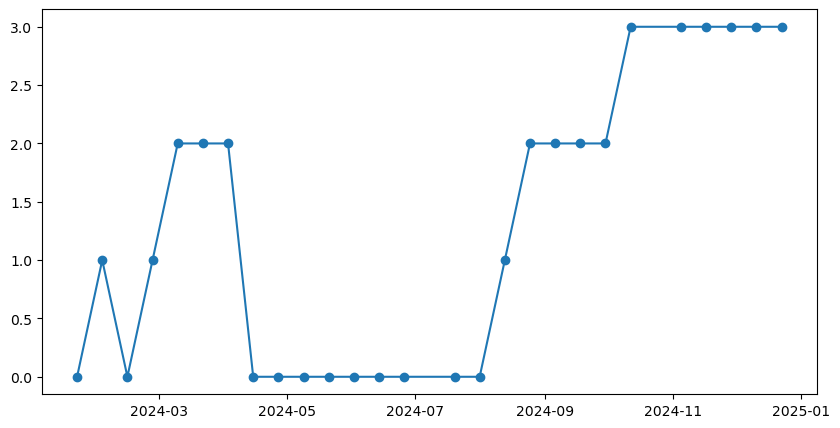

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dist_s1_dates, dist_status_ts, marker='o')

### DIST S1 Status

In [22]:
dist_cmap, dist_norm = get_dist_s1_mpl_cmap()

In [23]:
def read_file_partial(tif_path: str) -> float:
    return get_pixel_values_at_lon_lat(tif_path, lon=LON, lat=LAT, buffer_pixels=PIXEL_BUFFER)[0]

def get_windowed_status_profile(tif_path: str) -> float:
    return get_pixel_values_at_lon_lat(tif_path, lon=LON, lat=LAT, buffer_pixels=PIXEL_BUFFER)[1]

In [24]:
def get_row_col_from_profile_p(profile):
    return get_row_col_from_profile(profile, LON, LAT)

center_dist_s1 = get_row_col_from_profile_p(get_windowed_status_profile(status_files[0]))
center_dist_s1

(100, 100)

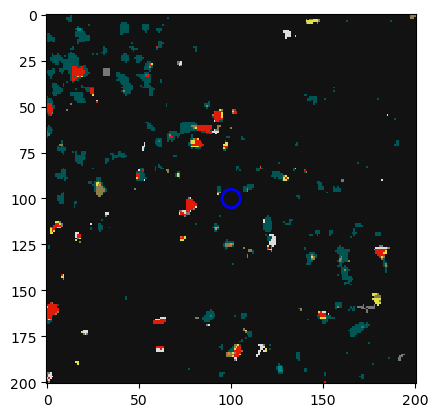

In [25]:
fig, ax = plt.subplots()
dist_status_image_ts = list(map(read_file_partial, status_files))
ax.imshow(dist_status_image_ts[-15], cmap=dist_cmap, norm=dist_norm, interpolation='none')

N =PIXEL_BUFFER
circle = plt.Circle((N, N), 5, color='blue', fill=False, linewidth=2)
ax.add_patch(circle)

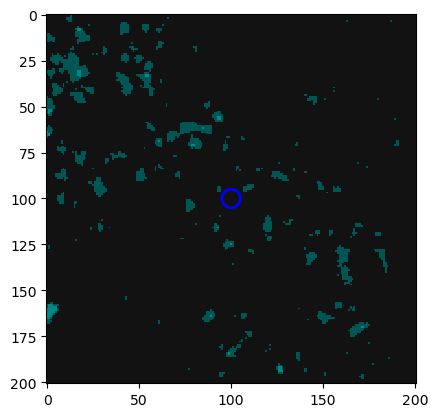

In [26]:
fig, ax = plt.subplots()
dist_acq_image_ts = list(map(read_file_partial, acq_files))
ax.imshow(dist_acq_image_ts[-15], cmap=dist_cmap, norm=dist_norm, interpolation='none')

N =PIXEL_BUFFER
circle = plt.Circle((N, N), 5, color='blue', fill=False, linewidth=2)
ax.add_patch(circle)

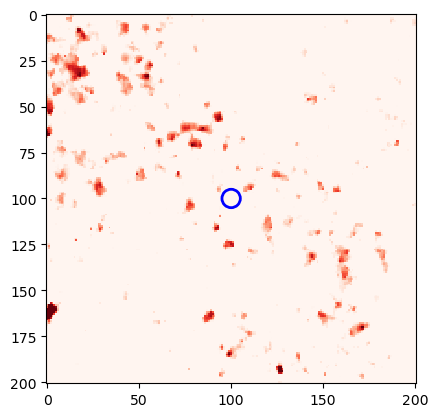

In [27]:
fig, ax = plt.subplots()
dist_metric_image_ts = list(map(read_file_partial, metric_files))
ax.imshow(dist_metric_image_ts[-15], interpolation='none', vmin=2, vmax=5, cmap='Reds')

N =PIXEL_BUFFER
circle = plt.Circle((N, N), 5, color='blue', fill=False, linewidth=2)
ax.add_patch(circle)

In [28]:
status_profile_window = get_windowed_status_profile(status_files[0])
status_profile_window

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 255.0, 'width': 201, 'height': 201, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 33N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32633"]]'), 'transform': Affine(30.0, 0.0, np.float64(365520.0),
       0.0, -30.0, np.float64(546810.0)), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}

In [29]:
with rasterio.open('status.tif', 'w', **status_profile_window) as ds:
    ds.write(dist_status_image_ts[-15], 1)
    ds.write_colormap(1, DIST_STATUS_CMAP)

# Bounding Box Geo

<Axes: >

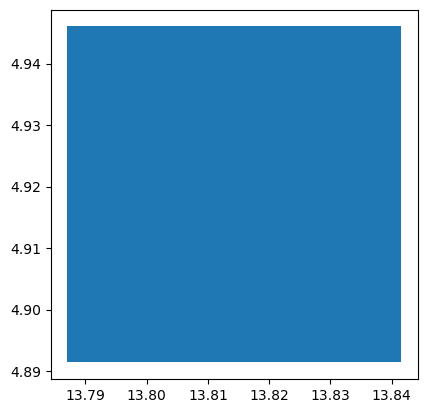

In [30]:
window_bbox = get_lat_lon_bounds_from_profile(status_profile_window)
df_window = gpd.GeoDataFrame(geometry=[box(*window_bbox)], crs='4326')
df_window.plot()

## Reference ts

In [31]:
df_ref_all = pd.read_csv('reference_tables/referenceTimeSeriesInterpolated16_16_goodFirst.csv')
df_ref_all.head()

,ID,overallLabel,Long,Lat,changetype,MGRS,2024-01-01,2024-01-02,2024-01-03,2024-01-04,...,2024-12-23,2024-12-24,2024-12-25,2024-12-26,2024-12-27,2024-12-28,2024-12-29,2024-12-30,2024-12-31,2025-01-01
0,30961_1,VLmin,13.854048,4.933158,Shifting cultivation,33NUF,noObs,noChange,noChange,noChange,...,VLmin,VLmin,VLmin,VLmin,VLmin,VLmin,VLmin,noObs,noObs,noObs
1,30961_2,VLmaj,13.852197,4.907920,Shifting cultivation,33NUF,noObs,noChange,noChange,noChange,...,VLmaj,VLmaj,VLmaj,VLmaj,VLmaj,VLmaj,VLmaj,noObs,noObs,noObs
2,30961_3,noChange,13.862138,4.948639,No Change,33NUF,noObs,noChange,noChange,noChange,...,noChange,noChange,noChange,noChange,noChange,noChange,noChange,noObs,noObs,noObs
3,30961_4,noChange,13.839969,4.939375,No Change,33NUF,noObs,noChange,noChange,noChange,...,noChange,noChange,noChange,noChange,noChange,noChange,noChange,noObs,noObs,noObs
4,30961_5,VLmaj,13.868099,4.942951,Shifting cultivation,33NUF,noObs,noChange,noChange,noChange,...,VLsub,VLsub,VLsub,VLsub,VLsub,VLsub,VLsub,noObs,noObs,noObs


In [37]:
def label_change(obs: str):
    if obs.lower()== 'noobs':
        return np.nan
    elif obs.lower() == 'nochange':
        return 0
    elif obs.lower() in ['ocmin', 'vlsub', 'vlmin']:
        return 1
    elif obs.lower() in ['ocmax', 'vlmaj', 'vlmajor']:
        return 2
    else:
        print(obs)
        raise ValueError('label not recognized')

In [38]:
df_site_ts = df_ref_all[df_ref_all.ID == SITE_ID]
date_columns = [c for c in df_site_ts.columns if c not in ['ID', 'overallLabel', 'Long', 'Lat', 'changetype', 'MGRS']]
df_site_ts = df_site_ts[date_columns].transpose().copy()
df_site_ts.columns = ['observation']
df_site_ts = df_site_ts.reset_index(drop=False, names='date')
df_site_ts['date'] = pd.to_datetime(df_site_ts['date'], utc=True)
df_site_ts['observation_label'] = df_site_ts.observation.map(label_change)
df_site_ts.head()

,date,observation,observation_label
0,2024-01-01 00:00:00+00:00,noObs,NaN
1,2024-01-02 00:00:00+00:00,noChange,0.0
2,2024-01-03 00:00:00+00:00,noChange,0.0
3,2024-01-04 00:00:00+00:00,noChange,0.0
4,2024-01-05 00:00:00+00:00,noChange,0.0


(array([19723., 19754., 19783., 19814., 19844., 19875., 19905., 19936.,
        19967., 19997., 20028., 20058., 20089.]),
 [Text(19723.0, 0, 'Jan 2024'),
  Text(19754.0, 0, 'Feb 2024'),
  Text(19783.0, 0, 'Mar 2024'),
  Text(19814.0, 0, 'Apr 2024'),
  Text(19844.0, 0, 'May 2024'),
  Text(19875.0, 0, 'Jun 2024'),
  Text(19905.0, 0, 'Jul 2024'),
  Text(19936.0, 0, 'Aug 2024'),
  Text(19967.0, 0, 'Sep 2024'),
  Text(19997.0, 0, 'Oct 2024'),
  Text(20028.0, 0, 'Nov 2024'),
  Text(20058.0, 0, 'Dec 2024'),
  Text(20089.0, 0, 'Jan 2025')])

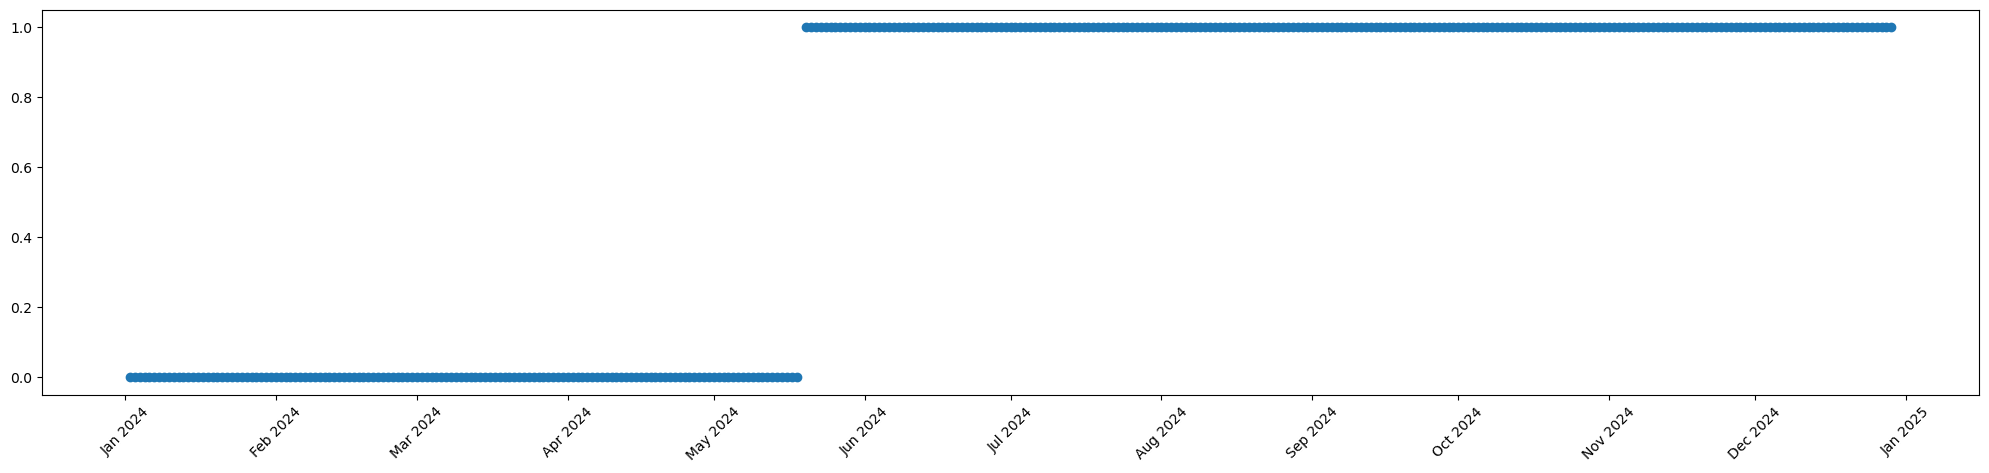

In [39]:
fig, ax = plt.subplots(figsize=(25, 5))
ax.plot(df_site_ts.date, df_site_ts.observation_label, marker='o')

#ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)

# OPERA RTC Data

In [ ]:
window_bbox = get_lat_lon_bounds_from_profile(status_profile_window)
window_bbox

(42.69550549350489, 53.53219595784021, 42.7893541858499, 53.58807259240784)

In [ ]:
window = get_window_around_lon_lat(status_files[0], lon=LON, lat=LAT, buffer_pixels=PIXEL_BUFFER)

In [ ]:
rtc_start_request.date().strftime('%Y-%m-%d'), ts_end_dist.date().strftime('%Y-%m-%d')

('2021-01-01', '2025-01-01')

In [ ]:
results_rtc = earthaccess_opera_geo_search(window_bbox, rtc_start_request.date().strftime('%Y-%m-%d'), ts_end_dist.date().strftime('%Y-%m-%d'), 'RTC-S1')

In [ ]:
flatten_earthaccess_result(results_rtc[0])

{'granule_id': 'OPERA_L2_RTC-S1_T021-043713-IW1_20210103T033006Z_20250909T180353Z_S1A_30_v1.0',
 'start_time': Timestamp('2021-01-03 03:30:06+0000', tz='UTC'),
 'end_time': Timestamp('2021-01-03 03:30:09+0000', tz='UTC'),
 'ascending_descending': 'DESCENDING',
 'beam_mode': 'IW',
 'bistatic_delay_correction': 'TRUE',
 'group_id': 'S1A_IWDV_0410_0416_035968_021',
 'look_direction': 'RIGHT',
 'noise_correction': 'TRUE',
 'opera_burst_id': 'T021_043713_IW1',
 'path_number': '21',
 'polarization': 'VV,VH',
 'post_processing_filter': 'FALSE',
 'processing_type': 'RTC',
 'product_version': '1.0',
 'radiometric_terrain_correction': 'TRUE',
 'static_tropo_correction': 'TRUE',
 'subswath_name': 'IW1',
 'wet_tropo_correction': 'FALSE',
 'url_h5': 'https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T021-043713-IW1_20210103T033006Z_20250909T180353Z_S1A_30_v1.0/OPERA_L2_RTC-S1_T021-043713-IW1_20210103T033006Z_20250909T180353Z_S1A_30_v1.0.h5',
 'url_vh': 'https://cumul

In [ ]:
df_lut = get_mgrs_burst_lut()
df_lut.head()

,jpl_burst_id,mgrs_tile_id,track_number,acq_group_id_within_mgrs_tile,orbit_pass,area_per_acq_group_km2,n_bursts_per_acq_group
0,T058-123813-IW3,01FBE,58,0,DESCENDING,3491,3
1,T058-123814-IW3,01FBE,58,0,DESCENDING,3491,3
2,T058-123815-IW3,01FBE,58,0,DESCENDING,3491,3
3,T081-173674-IW1,01FBE,81,1,ASCENDING,3572,2
4,T081-173675-IW1,01FBE,81,1,ASCENDING,3572,2


In [ ]:
metadata = list(map(flatten_earthaccess_result, results_rtc))
df_rtc = gpd.GeoDataFrame(metadata)
df_rtc = df_rtc[df_rtc.contains(site_geo)].reset_index(drop=True)
df_rtc['track_number'] = df_rtc.granule_id.map(get_track_number)
df_rtc['mgrs_tile_id'] = MGRS_TILE_ID
df_rtc['jpl_burst_id'] = df_rtc.granule_id.map(get_burst_id)
df_rtc['acq_time'] = df_rtc.granule_id.map(lambda x: pd.to_datetime(get_acquisition_datetime(x)))
df_rtc['overlap_area'] = df_rtc.geometry.intersection(df_window.geometry).area
df_rtc['repeat_pass_int'] = (df_rtc.start_time - pd.Timestamp('2014-01-01', tz='UTC')).dt.total_seconds() // (60 * 60 * 24 * 6)
df_rtc = df_rtc.merge(df_lut[['jpl_burst_id', 'acq_group_id_within_mgrs_tile', 'mgrs_tile_id']], on=['jpl_burst_id', 'mgrs_tile_id'], how='left')
df_rtc = df_rtc.sort_values(by=['repeat_pass_int', 'overlap_area'], ascending=False)
print(df_rtc.shape)
df_rtc = df_rtc.groupby(['repeat_pass_int', 'acq_group_id_within_mgrs_tile']).first().reset_index()
print(df_rtc.shape)
df_rtc.head()

(492, 32)
(238, 32)


/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_9397/3577463840.py:8: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  df_rtc['overlap_area'] = df_rtc.geometry.intersection(df_window.geometry).area
/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_9397/3577463840.py:8: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  df_rtc['overlap_area'] = df_rtc.geometry.intersection(df_window.geometry).area


,repeat_pass_int,acq_group_id_within_mgrs_tile,granule_id,start_time,end_time,ascending_descending,beam_mode,bistatic_delay_correction,group_id,look_direction,...,url_vh,url_vv,url_mask,geometry,beam_mode_desc,track_number,mgrs_tile_id,jpl_burst_id,acq_time,overlap_area
0,426.0,0,OPERA_L2_RTC-S1_T021-043713-IW1_20210103T03300...,2021-01-03 03:30:06+00:00,2021-01-03 03:30:09+00:00,DESCENDING,IW,TRUE,S1A_IWDV_0410_0416_035968_021,RIGHT,...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((43.40063 53.60915, 41.99746 53.77272...",None,21,38ULE,T021-043713-IW1,2021-01-03 03:30:06+00:00,0.005244
1,427.0,4,OPERA_L2_RTC-S1_T123-262802-IW3_20210110T03215...,2021-01-10 03:21:55+00:00,2021-01-10 03:21:58+00:00,DESCENDING,IW,TRUE,S1A_IWDV_0411_0417_036070_123,RIGHT,...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((42.80444 53.72623, 41.52975 53.84657...",None,123,38ULE,T123-262802-IW3,2021-01-10 03:21:55+00:00,NaN
2,428.0,0,OPERA_L2_RTC-S1_T021-043713-IW1_20210115T03300...,2021-01-15 03:30:05+00:00,2021-01-15 03:30:08+00:00,DESCENDING,IW,TRUE,S1A_IWDV_0410_0416_036143_021,RIGHT,...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((43.39988 53.6091, 41.99666 53.77266,...",None,21,38ULE,T021-043713-IW1,2021-01-15 03:30:05+00:00,NaN
3,429.0,4,OPERA_L2_RTC-S1_T123-262802-IW3_20210122T03215...,2021-01-22 03:21:54+00:00,2021-01-22 03:21:57+00:00,DESCENDING,IW,TRUE,S1A_IWDV_0411_0417_036245_123,RIGHT,...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((42.8056 53.72633, 41.53089 53.84669,...",None,123,38ULE,T123-262802-IW3,2021-01-22 03:21:54+00:00,NaN
4,430.0,0,OPERA_L2_RTC-S1_T021-043713-IW1_20210127T03300...,2021-01-27 03:30:05+00:00,2021-01-27 03:30:08+00:00,DESCENDING,IW,TRUE,S1A_IWDV_0411_0416_036318_021,RIGHT,...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((43.39952 53.60914, 41.9963 53.7727, ...",None,21,38ULE,T021-043713-IW1,2021-01-27 03:30:05+00:00,NaN


<Axes: >

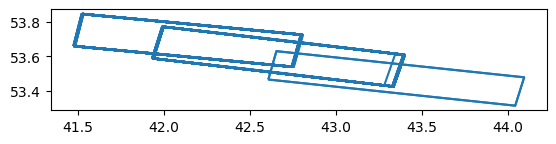

In [ ]:
df_rtc.boundary.plot()

In [ ]:
out_data = read_multiple_earthdata_urls(df_rtc.url_vv.tolist(), extent=window_bbox, max_workers=10)
vv_arrs, vv_profs = out_data

100%|██████████| 238/238 [00:53<00:00,  4.42it/s]


<Axes: >

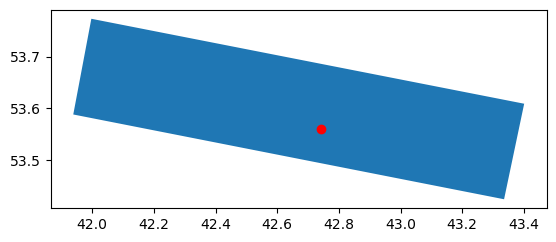

In [ ]:
fig, ax = plt.subplots()
df_rtc.iloc[:1].plot(ax=ax)
df_point_aoi.plot(ax=ax, color='red')

In [ ]:
df_rtc.iloc[0].geometry.contains(df_point_aoi.geometry.iloc[0])

True

In [ ]:
df_rtc.url_vh.tolist()[0]

'https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T021-043713-IW1_20210103T033006Z_20250909T180353Z_S1A_30_v1.0/OPERA_L2_RTC-S1_T021-043713-IW1_20210103T033006Z_20250909T180353Z_S1A_30_v1.0_VH.tif'

In [ ]:
out_data = read_multiple_earthdata_urls(df_rtc.url_vh.tolist(), extent=window_bbox, max_workers=10)
vh_arrs, vh_profs = out_data

100%|██████████| 238/238 [00:47<00:00,  5.02it/s]


In [ ]:
vv_arrs_tv = despeckle_rtc_arrs_with_tv(vv_arrs, preserve_exterior_mask=True, n_jobs=10)
vh_arrs_tv = despeckle_rtc_arrs_with_tv(vh_arrs, preserve_exterior_mask=True, n_jobs=10)

Despeckling: 100%|██████████| 238/238 [00:04<00:00, 50.03it/s]


In [ ]:
vh_profs[0]

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': np.int64(198), 'height': np.int64(219), 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 37N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",39],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32637"]]'), 'transform': Affine(30.0, 0.0, np.float64(744870.0),
       0.0, -30.0, np.float64(5944380.0)), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}

In [ ]:
def get_row_col_from_profile_p(profile):
    return get_row_col_from_profile(profile, LON, LAT)

centers_rtc = list(map(get_row_col_from_profile_p, vh_profs))
centers_rtc[-3:]

[(100, 107), (109, 99), (100, 107)]

In [ ]:
vv_pixel_ts = np.array([vv[c] for (vv, c) in zip(vv_arrs_tv, centers_rtc)])
vh_pixel_ts = np.array([vh[c] for (vh, c) in zip(vh_arrs_tv, centers_rtc)])
rtc_dates = df_rtc.acq_time

In [ ]:
valid_pixels = ~np.isnan(vv_pixel_ts)
vv_pixel_ts = vv_pixel_ts[valid_pixels]
vh_pixel_ts = vh_pixel_ts[valid_pixels]
rtc_dates = rtc_dates[valid_pixels]
vh_profs = [vh_profs[i] for i in range(len(vh_profs)) if valid_pixels[i]]
vv_profs = [vv_profs[i] for i in range(len(vv_profs)) if valid_pixels[i]]
vv_arrs_tv = [vv_arrs_tv[i] for i in range(len(vv_arrs_tv)) if valid_pixels[i]]
vh_arrs_tv = [vh_arrs_tv[i] for i in range(len(vh_arrs_tv)) if valid_pixels[i]]
vv_arrs = [vv_arrs[i] for i in range(len(vv_arrs)) if valid_pixels[i]]
vh_arrs = [vh_arrs[i] for i in range(len(vh_arrs)) if valid_pixels[i]]
df_rtc = df_rtc[valid_pixels].reset_index(drop=True)


<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:6: SyntaxWarning: invalid escape sequence '\g'
/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_9397/1358849417.py:6: SyntaxWarning: invalid escape sequence '\g'
  ax_vv.set_ylabel('$\gamma_{VV}$', color='blue')


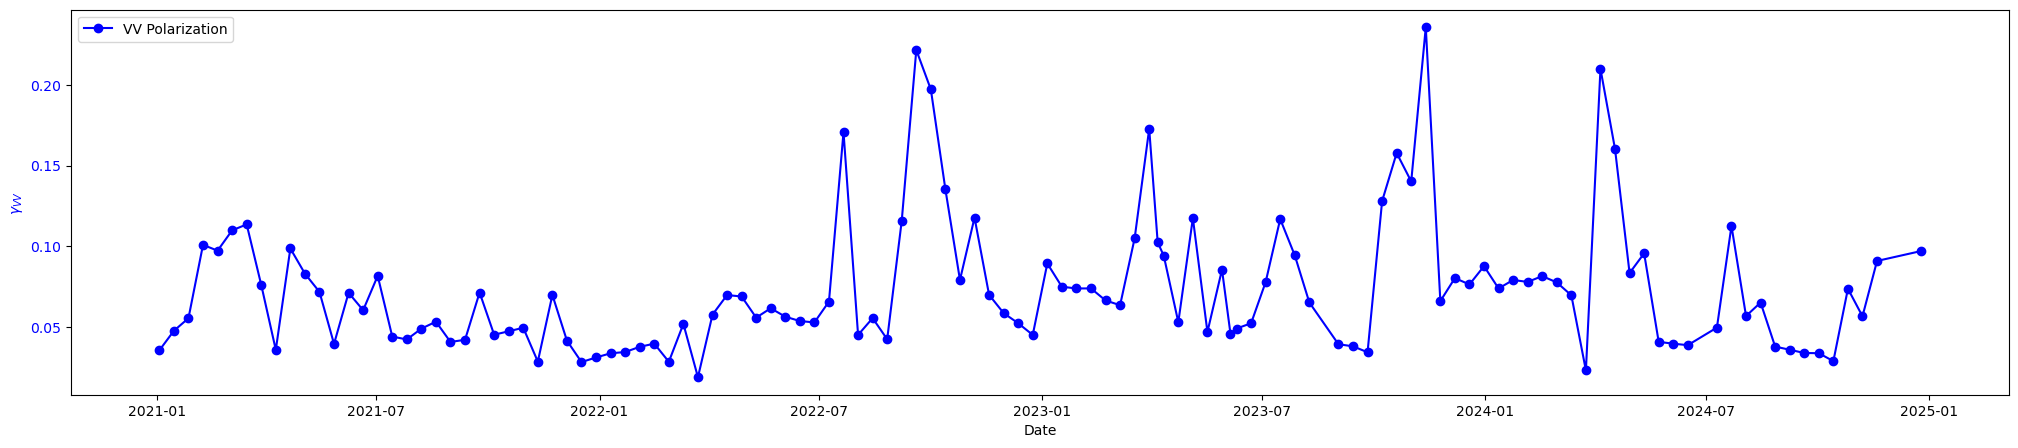

In [ ]:
import matplotlib.pyplot as plt

fig, ax_vv = plt.subplots(figsize=(25, 5))

vv_ln = ax_vv.plot(rtc_dates, vv_pixel_ts, marker='o', color='blue', label='VV Polarization')
ax_vv.set_ylabel('$\gamma_{VV}$', color='blue')
ax_vv.tick_params(axis='y', labelcolor='blue')
ax_vv.set_xlabel('Date')

ax_vv.legend( loc='upper left')


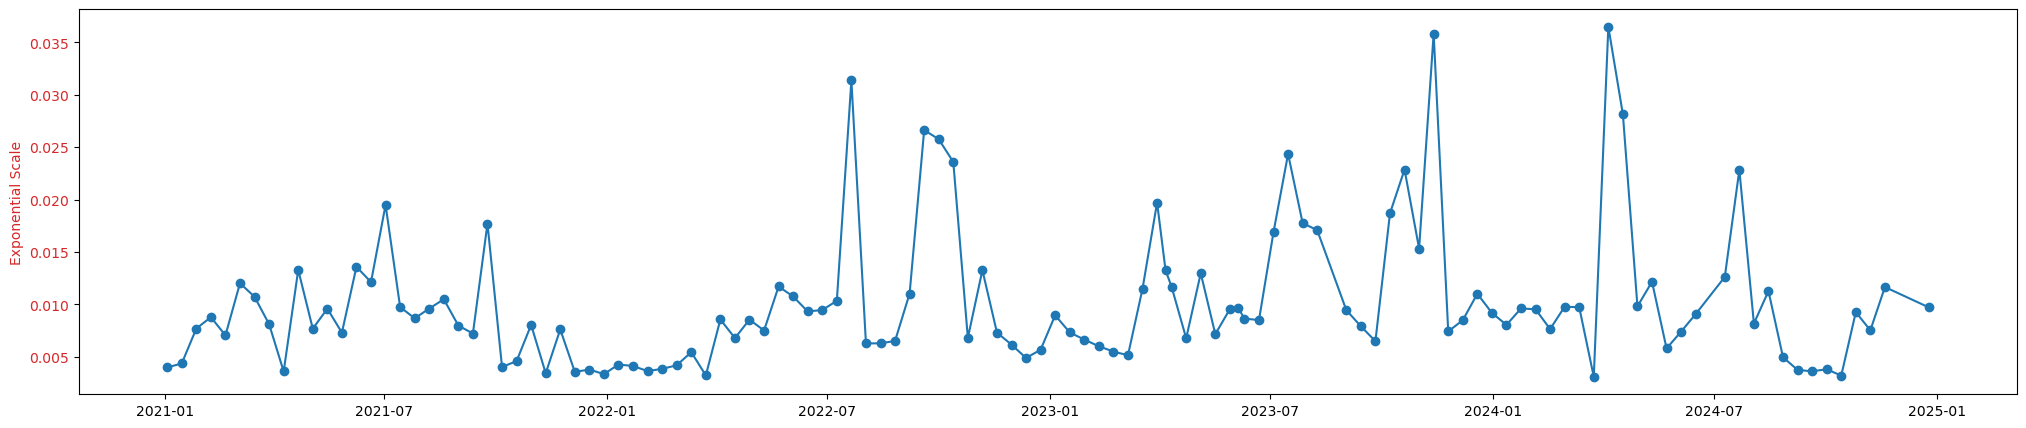

In [ ]:
fig, ax_vh = plt.subplots(figsize=(25, 5))

vh_ln = ax_vh.plot(rtc_dates, vh_pixel_ts, marker='o')
ax_vh.set_ylabel('Exponential Scale', color='tab:red')
ax_vh.tick_params(axis='y', labelcolor='tab:red')


In [ ]:
# vv_pixel_ts = np.array([vv[c] for (vv, c) in zip(vv_arrs_tv, centers_rtc)])
# vh_pixel_ts = np.array([vh[c] for (vh, c) in zip(vh_arrs_tv, centers_rtc)])

# vv_pixel_ts_obs = vv_pixel_ts[~np.isnan(vv_pixel_ts)]
# vh_pixel_ts_obs = vh_pixel_ts[~np.isnan(vh_pixel_ts)]

# rtc_dates = df_rtc.start_time.values
# rtc_dates_obs = rtc_dates[~np.isnan(vv_pixel_ts)]
# rtc_dates_nans = rtc_dates[np.isnan(vv_pixel_ts)]

# rtc_nans = np.zeros(np.isnan(vv_pixel_ts).sum())

# DIST-HLS


In [ ]:
results_dist_hls = earthaccess_opera_geo_search(window_bbox, start_date_dist, end_date_dist, 'DIST-HLS-ALERT')

In [ ]:
dict(results_dist_hls[0])

{'meta': {'concept-type': 'granule',
  'concept-id': 'G2878082135-LPCLOUD',
  'revision-id': 1,
  'native-id': 'OPERA_L3_DIST-ALERT-HLS_T38ULE_20240113T083219Z_20240208T164528Z_S2B_30_v1',
  'collection-concept-id': 'C2746980408-LPCLOUD',
  'provider-id': 'LPCLOUD',
  'format': 'application/vnd.nasa.cmr.umm+json',
  'revision-date': '2024-02-26T17:13:41.232Z'},
 'umm': {'TemporalExtent': {'RangeDateTime': {'BeginningDateTime': '2024-01-13T08:35:01.295700Z',
    'EndingDateTime': '2024-01-13T08:35:01.295700Z'}},
  'GranuleUR': 'OPERA_L3_DIST-ALERT-HLS_T38ULE_20240113T083219Z_20240208T164528Z_S2B_30_v1',
  'AdditionalAttributes': [{'Name': 'Input_DIST-ALERT_granule',
    'Values': ['OPERA_L3_DIST-ALERT-HLS_T38ULE_20231129T083301Z_20231223T042250Z_S2A_30_v1']},
   {'Name': 'BaselineCalendarWindow', 'Values': ['+/- 15 days']},
   {'Name': 'BaselineYearWindow', 'Values': ['3']},
   {'Name': 'BaselineImageIds',
    'Values': ['HLS.L30.T38ULE.2023020T081135.v2.0',
     'HLS.L30.T38ULE.2023021

In [ ]:
def get_mgrs_tile_id(granule_id: str) -> str:
    return granule_id.split('_')[3]

In [ ]:
metadata = list(map(flatten_earthaccess_result, results_dist_hls))
df_dist_hls = gpd.GeoDataFrame(metadata)
df_dist_hls = df_dist_hls[df_dist_hls.mgrs_tile_id == MGRS_TILE_ID].reset_index(drop=True)
df_dist_hls = df_dist_hls.sort_values(by='start_time', ascending=True).reset_index(drop=True)
df_dist_hls.head()

,granule_id,start_time,end_time,input_dist-alert_granule,baselinecalendarwindow,baselineyearwindow,baselineimageids,validationlevel,hlsgranuleur,sensor_product_id,...,url_gen-dist-status,url_gen-anom,url_gen-anom-max,url_gen-dist-conf,url_gen-dist-date,url_gen-dist-count,url_gen-dist-dur,url_gen-last-date,url_data-mask,geometry
0,OPERA_L3_DIST-ALERT-HLS_T38ULE_20240113T083219...,2024-01-13 08:35:01.295700+00:00,2024-01-13 08:35:01.295700+00:00,OPERA_L3_DIST-ALERT-HLS_T38ULE_20231129T083301...,+/- 15 days,3,"HLS.L30.T38ULE.2023020T081135.v2.0,HLS.L30.T38...",1,HLS.S30.T38ULE.2024013T083219.v2.0,S2B_MSIL1C_20240113T083219_N0510_R021_T38ULE_2...,...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,"POLYGON ((42.01091 53.12365, 42.53577 53.13621..."
1,OPERA_L3_DIST-ALERT-HLS_T38ULE_20240123T081107...,2024-01-23 08:11:07.629812+00:00,2024-01-23 08:11:31.512355+00:00,OPERA_L3_DIST-ALERT-HLS_T38ULE_20240122T081231...,+/- 15 days,3,"HLS.S30.T38ULE.2023025T082129.v2.0,HLS.S30.T38...",1,HLS.L30.T38ULE.2024023T081107.v2.0,"LC09_L1TP_175022_20240123_20240123_02_T1,LC09_...",...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,"POLYGON ((42.01091 53.12365, 42.75355 53.14025..."
2,OPERA_L3_DIST-ALERT-HLS_T38ULE_20240123T083149...,2024-01-23 08:35:02.248680+00:00,2024-01-23 08:35:02.248680+00:00,OPERA_L3_DIST-ALERT-HLS_T38ULE_20240123T081107...,+/- 15 days,3,"HLS.S30.T38ULE.2023025T082129.v2.0,HLS.S30.T38...",1,HLS.S30.T38ULE.2024023T083149.v2.0,S2B_MSIL1C_20240123T083149_N0510_R021_T38ULE_2...,...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,"POLYGON ((42.01091 53.12365, 42.53401 53.13564..."
3,OPERA_L3_DIST-ALERT-HLS_T38ULE_20240128T083211...,2024-01-28 08:34:57.925670+00:00,2024-01-28 08:34:57.925670+00:00,OPERA_L3_DIST-ALERT-HLS_T38ULE_20240125T075910...,+/- 15 days,3,"HLS.S30.T38ULE.2023025T082129.v2.0,HLS.S30.T38...",1,HLS.S30.T38ULE.2024028T083211.v2.0,S2A_MSIL1C_20240128T083211_N0510_R021_T38ULE_2...,...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,"POLYGON ((42.01091 53.12365, 42.54745 53.13591..."
4,OPERA_L3_DIST-ALERT-HLS_T38ULE_20240208T081113...,2024-02-08 08:11:13.598920+00:00,2024-02-08 08:11:37.481464+00:00,OPERA_L3_DIST-ALERT-HLS_T38ULE_20240128T083211...,+/- 15 days,3,"HLS.S30.T38ULE.2021048T082919.v2.0,HLS.S30.T38...",1,HLS.L30.T38ULE.2024039T081113.v2.0,"LC09_L1TP_175022_20240208_20240208_02_T1,LC09_...",...,https://data.lpdaac.earthdataclou

In [ ]:
df_dist_hls.columns

Index(['granule_id', 'start_time', 'end_time', 'input_dist-alert_granule',
       'baselinecalendarwindow', 'baselineyearwindow', 'baselineimageids',
       'validationlevel', 'hlsgranuleur', 'sensor_product_id',
       'spatial_coverage', 'mgrs_tile_id', 'hls_processing_time',
       'sensing_time', 'horizontal_cs_code', 'horizontal_cs_name', 'ulx',
       'uly', 'url_veg-dist-status', 'url_veg-ind', 'url_veg-anom',
       'url_veg-hist', 'url_veg-anom-max', 'url_veg-dist-conf',
       'url_veg-dist-date', 'url_veg-dist-count', 'url_veg-dist-dur',
       'url_veg-last-date', 'url_gen-dist-status', 'url_gen-anom',
       'url_gen-anom-max', 'url_gen-dist-conf', 'url_gen-dist-date',
       'url_gen-dist-count', 'url_gen-dist-dur', 'url_gen-last-date',
       'url_data-mask', 'geometry'],
      dtype='object')

In [ ]:
out_data = read_multiple_earthdata_urls(df_dist_hls['url_gen-dist-status'].tolist(), extent=window_bbox, max_workers=10)
hls_gen_status_arrs, gen_status_profs = out_data

100%|██████████| 151/151 [00:04<00:00, 37.42it/s]


In [ ]:
df_dist_hls['url_veg-dist-status'].tolist()[6]

'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/OPERA_L3_DIST-ALERT-HLS_V1/OPERA_L3_DIST-ALERT-HLS_T38ULE_20240209T082019Z_20240213T072456Z_S2B_30_v1/OPERA_L3_DIST-ALERT-HLS_T38ULE_20240209T082019Z_20240213T072456Z_S2B_30_v1_VEG-DIST-STATUS.tif'

In [ ]:
out_data = read_multiple_earthdata_urls(df_dist_hls['url_veg-dist-status'].tolist(), extent=window_bbox, max_workers=5)
hls_veg_status_arrs, _ = out_data

100%|██████████| 151/151 [00:07<00:00, 19.01it/s]


In [ ]:
out_data = read_multiple_earthdata_urls(df_dist_hls['url_gen-anom'].tolist(), extent=window_bbox, max_workers=5)
hls_gen_anom_arrs, _ = out_data

100%|██████████| 151/151 [00:08<00:00, 18.61it/s]


In [ ]:
out_data = read_multiple_earthdata_urls(df_dist_hls['url_veg-anom'].tolist(), extent=window_bbox, max_workers=5)
hls_veg_anom_arrs, _ = out_data

100%|██████████| 151/151 [00:07<00:00, 20.19it/s]


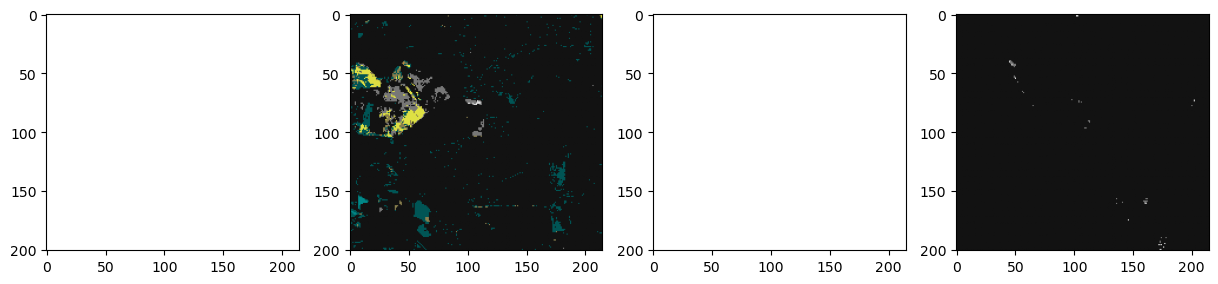

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(15, 10))

veg_anom_arr_plot = np.ma.masked_equal(hls_veg_anom_arrs[10], 255)
ax[0].imshow(veg_anom_arr_plot, vmin=0, vmax=100)
ax[1].imshow(hls_veg_status_arrs[10], cmap=dist_cmap, norm=dist_norm)

gen_anom_arr_plot = np.ma.masked_equal(hls_gen_anom_arrs[10], -1)
ax[2].imshow(gen_anom_arr_plot, vmin=0, vmax=100)
ax[3].imshow(hls_gen_status_arrs[10], cmap=dist_cmap, norm=dist_norm)

In [ ]:
def get_row_col_from_profile_p(profile):
    return get_row_col_from_profile(profile, LON, LAT)

centers_dist_hls = list(map(get_row_col_from_profile_p, gen_status_profs))
centers_dist_hls[-3:]

[(100, 107), (100, 107), (100, 107)]

(-1.0, 9.0)

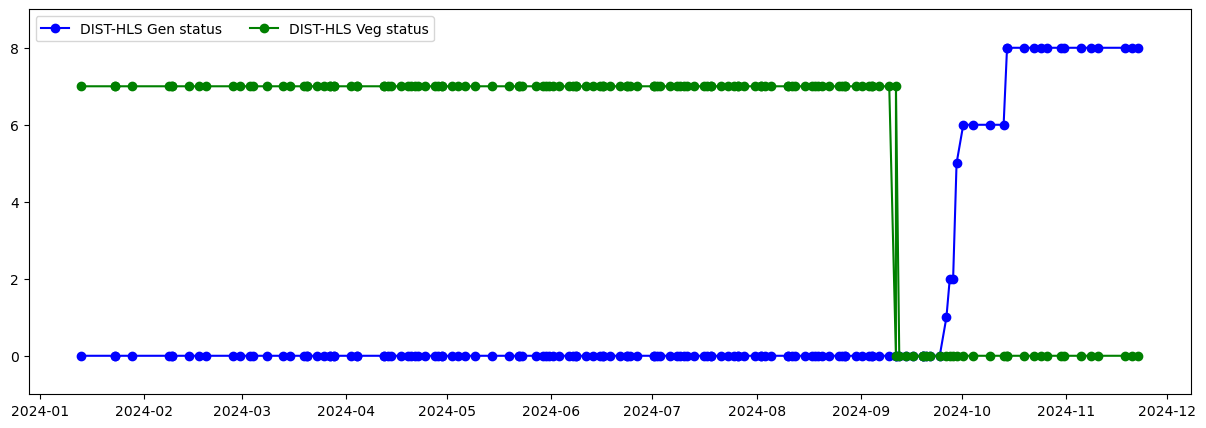

In [ ]:
hls_veg_status_ts = np.array([vv[c] for (vv, c) in zip(hls_veg_status_arrs, centers_dist_hls)])
hls_gen_status_ts = np.array([vh[c] for (vh, c) in zip(hls_gen_status_arrs, centers_dist_hls)])

dist_hls_dates = pd.to_datetime(df_dist_hls.start_time)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(dist_hls_dates, hls_gen_status_ts, marker='o', label='DIST-HLS Gen status', color='blue')
ax.plot(dist_hls_dates, hls_veg_status_ts, marker='o', label='DIST-HLS Veg status', color='green')
ax.legend(loc='upper left', ncol=4)
ax.set_ylim(-1, 9)

In [ ]:
dist_hls_dates = df_dist_hls.start_time.tolist()

# Land Cover

In [ ]:
X_esa, p_esa = get_raster_from_tiles(window_bbox, 
                                     tile_shortname='esa_world_cover_2021')

Reading tile imagery: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s]


In [ ]:
X_esa, p_esa = get_raster_from_tiles(window_bbox, 
                                     tile_shortname='esa_world_cover_2021')

Reading tile imagery: 100%|██████████| 1/1 [00:00<00:00,  1.18it/s]


In [ ]:
legend_data = p_esa['tags']['legend'].split('\n')
legend_data = list(filter(lambda x: x, legend_data))
ticks = [int(d.split()[0]) for d in legend_data]
tick_labels = [' '.join(d.split()[1:]) for d in legend_data]

In [ ]:
esa_dict = dict(zip(ticks, tick_labels))
esa_dict

{10: 'Tree cover',
 20: 'Shrubland',
 30: 'Grassland',
 40: 'Cropland',
 50: 'Built-up',
 60: 'Bare/sparse vegetation',
 70: 'Snow and ice',
 80: 'Permanent water bodies',
 90: 'Herbaceous wetland',
 95: 'Mangroves',
 100: 'Moss and lichen'}

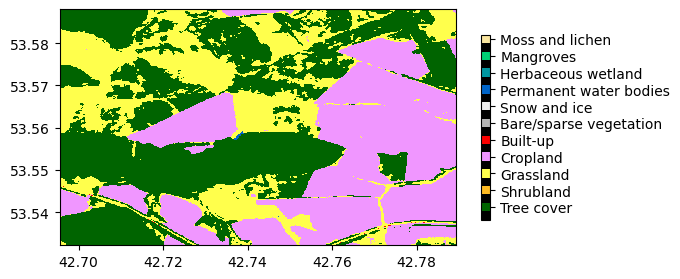

In [ ]:
fig, ax = plt.subplots()

colormap = p_esa['colormap'][1]  # We store each colormap as a dictionary associated to its channel
cmap = ListedColormap([np.array(colormap[key]) / 255 for key in range(256)])
im_data = show(X_esa[0, ...], 
               transform=p_esa['transform'], 
               cmap=cmap, 
               interpolation='none', 
               vmin=0, 
               vmax=255, 
               ax=ax)

im = im_data.get_images()[0]
bounds_fig = sorted([0] + [t - .5 for t in ticks] + [t + .5 for t in ticks])
cbar=fig.colorbar(im, 
                  ax=ax, 
                  shrink=0.5, 
                  pad=0.05, 
                  boundaries=bounds_fig, 
                  cmap=cmap,
                  ticks=np.array(ticks)
                 ) 
norm = BoundaryNorm(bounds_fig, cmap.N)
cbar.set_ticklabels(tick_labels)

In [ ]:
legend_data

['10  Tree cover',
 '20  Shrubland',
 '30  Grassland',
 '40  Cropland',
 '50  Built-up',
 '60  Bare/sparse vegetation',
 '70  Snow and ice',
 '80  Permanent water bodies',
 '90  Herbaceous wetland',
 '95  Mangroves',
 '100 Moss and lichen']

In [ ]:
from rasterio.transform import rowcol
r, c = rowcol(p_esa['transform'], LON, LAT)

esa_label = X_esa[0, r, c]
esa_class = esa_dict[esa_label]
print(f'{esa_label}: {esa_class}')

30: Grassland


# Basemap Imagery

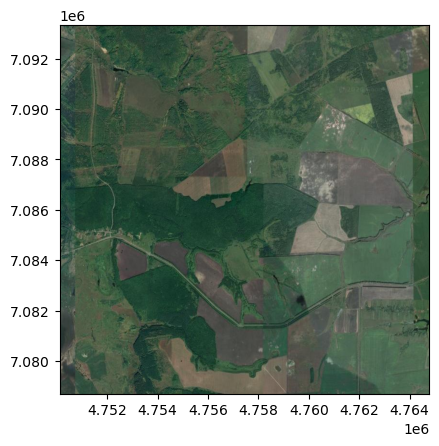

In [ ]:
img, ext = get_basemap_for_matplotlib(*window_bbox, zoom='auto', source='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}')

plt.imshow(img, extent=ext)
plt.show()

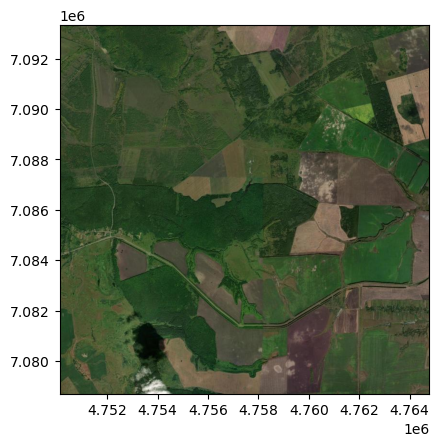

In [ ]:
img, ext = get_basemap_for_matplotlib(*window_bbox, zoom='auto')

plt.imshow(img, extent=ext)
plt.show()

<Axes: >

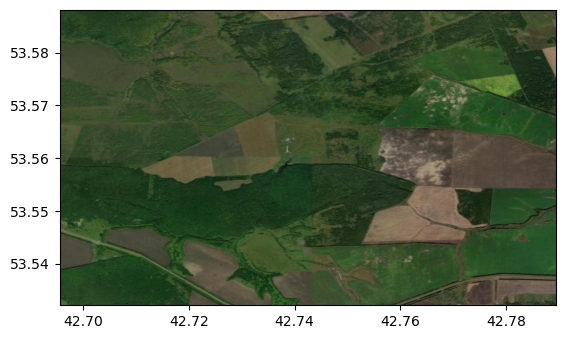

In [ ]:
from dem_stitcher.rio_tools import reproject_arr_to_match_profile
X_esri_orig, p_esri_orig = get_basemap_for_rasterio(*window_bbox, zoom='auto', nodata=None)
X_esri = X_esri_orig[:3, ...].astype(np.float32) / 255.
p_esri = p_esri_orig.copy()
p_esri['dtype'] = np.float32
p_esri['count'] = 3
X_esri, p_esri = reproject_arr_to_match_profile(X_esri, p_esri, p_esa, resampling='bilinear')

fig, ax = plt.subplots()
show(X_esri, transform=p_esri['transform'], ax=ax)

<Axes: >

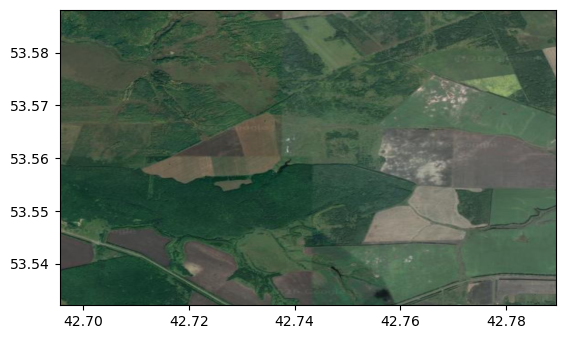

In [ ]:
from dem_stitcher.rio_tools import reproject_arr_to_match_profile
X_goog_orig, p_goog_orig = get_basemap_for_rasterio(*window_bbox, zoom='auto', source='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}', nodata=None)

X_goog = X_goog_orig[:3, ...].astype(np.float32) / 255.
p_goog = p_goog_orig.copy()
p_goog['dtype'] = np.float32
p_goog['count'] = 3
X_goog, p_goog = reproject_arr_to_match_profile(X_goog, p_goog, p_esa, resampling='bilinear')

fig, ax = plt.subplots()
show(X_goog, transform=p_goog['transform'], ax=ax)

# Location

In [ ]:
import reverse_geocoder as rg

coordinates = (LON, LAT) # New York City
results = rg.search(coordinates) # Returns a list of dicts

print(f"City: {results[0]['name']}, Country: {results[0]['cc']}")

Loading formatted geocoded file...
City: Zhanaozen, Country: KZ


# Final Images

## Create Img Directories

In [ ]:
site_dir = out_dir / SITE_ID

png_dir = site_dir / 'pngs'

png_dir.mkdir(exist_ok=True, parents=True)

## Location Panel

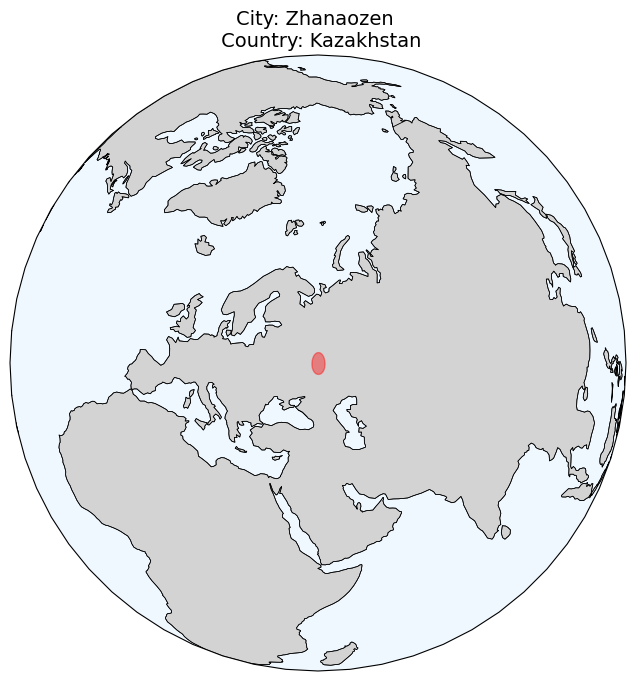

In [ ]:
bbox_geom = box(*window_bbox).buffer(2)
center_lon, center_lat = bbox_geom.centroid.coords[0]
projection = ccrs.Orthographic(central_longitude=center_lon, central_latitude=center_lat)

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=projection)

ax.set_global() # Show the full sphere
ax.add_feature(cfeature.OCEAN, color='aliceblue')
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_geometries([bbox_geom], crs=ccrs.PlateCarree(), 
                  facecolor='red', alpha=0.4, edgecolor='red', linewidth=1)


country_ob = pycountry.countries.get(alpha_2=results[0]['cc'])
country_name = country_ob.name if country_ob else "Unknown Country"
ax.set_title(f"City: {results[0]['name']} \n Country: {country_name}", fontsize=14)
plt.show()

In [ ]:
def plot_globe_in_mosaic_plot(fig, axs, ax_label):
    pos = axs[ax_label].get_subplotspec() 
    axs[ax_label].remove()               
    bbox_geom = box(*window_bbox).buffer(2)
    center_lon, center_lat = bbox_geom.centroid.coords[0]
    projection = ccrs.Orthographic(central_longitude=center_lon, central_latitude=center_lat)

    axs[ax_label] = fig.add_subplot(pos, projection=projection)
    
    axs[ax_label].set_global() # Show the full sphere
    axs[ax_label].add_feature(cfeature.OCEAN, color='aliceblue')
    axs[ax_label].add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', linewidth=0.5)
    axs[ax_label].add_feature(cfeature.COASTLINE, linewidth=0.5)
    axs[ax_label].add_geometries([bbox_geom], crs=ccrs.PlateCarree(), 
                      facecolor='red', alpha=0.4, edgecolor='red', linewidth=1)
    
    
    country_ob = pycountry.countries.get(alpha_2=results[0]['cc'])
    country_name = country_ob.name if country_ob else "Unknown Country"
    axs[ax_label].set_title(f"City: {results[0]['name']} \n Country: {country_name}", fontsize=14)

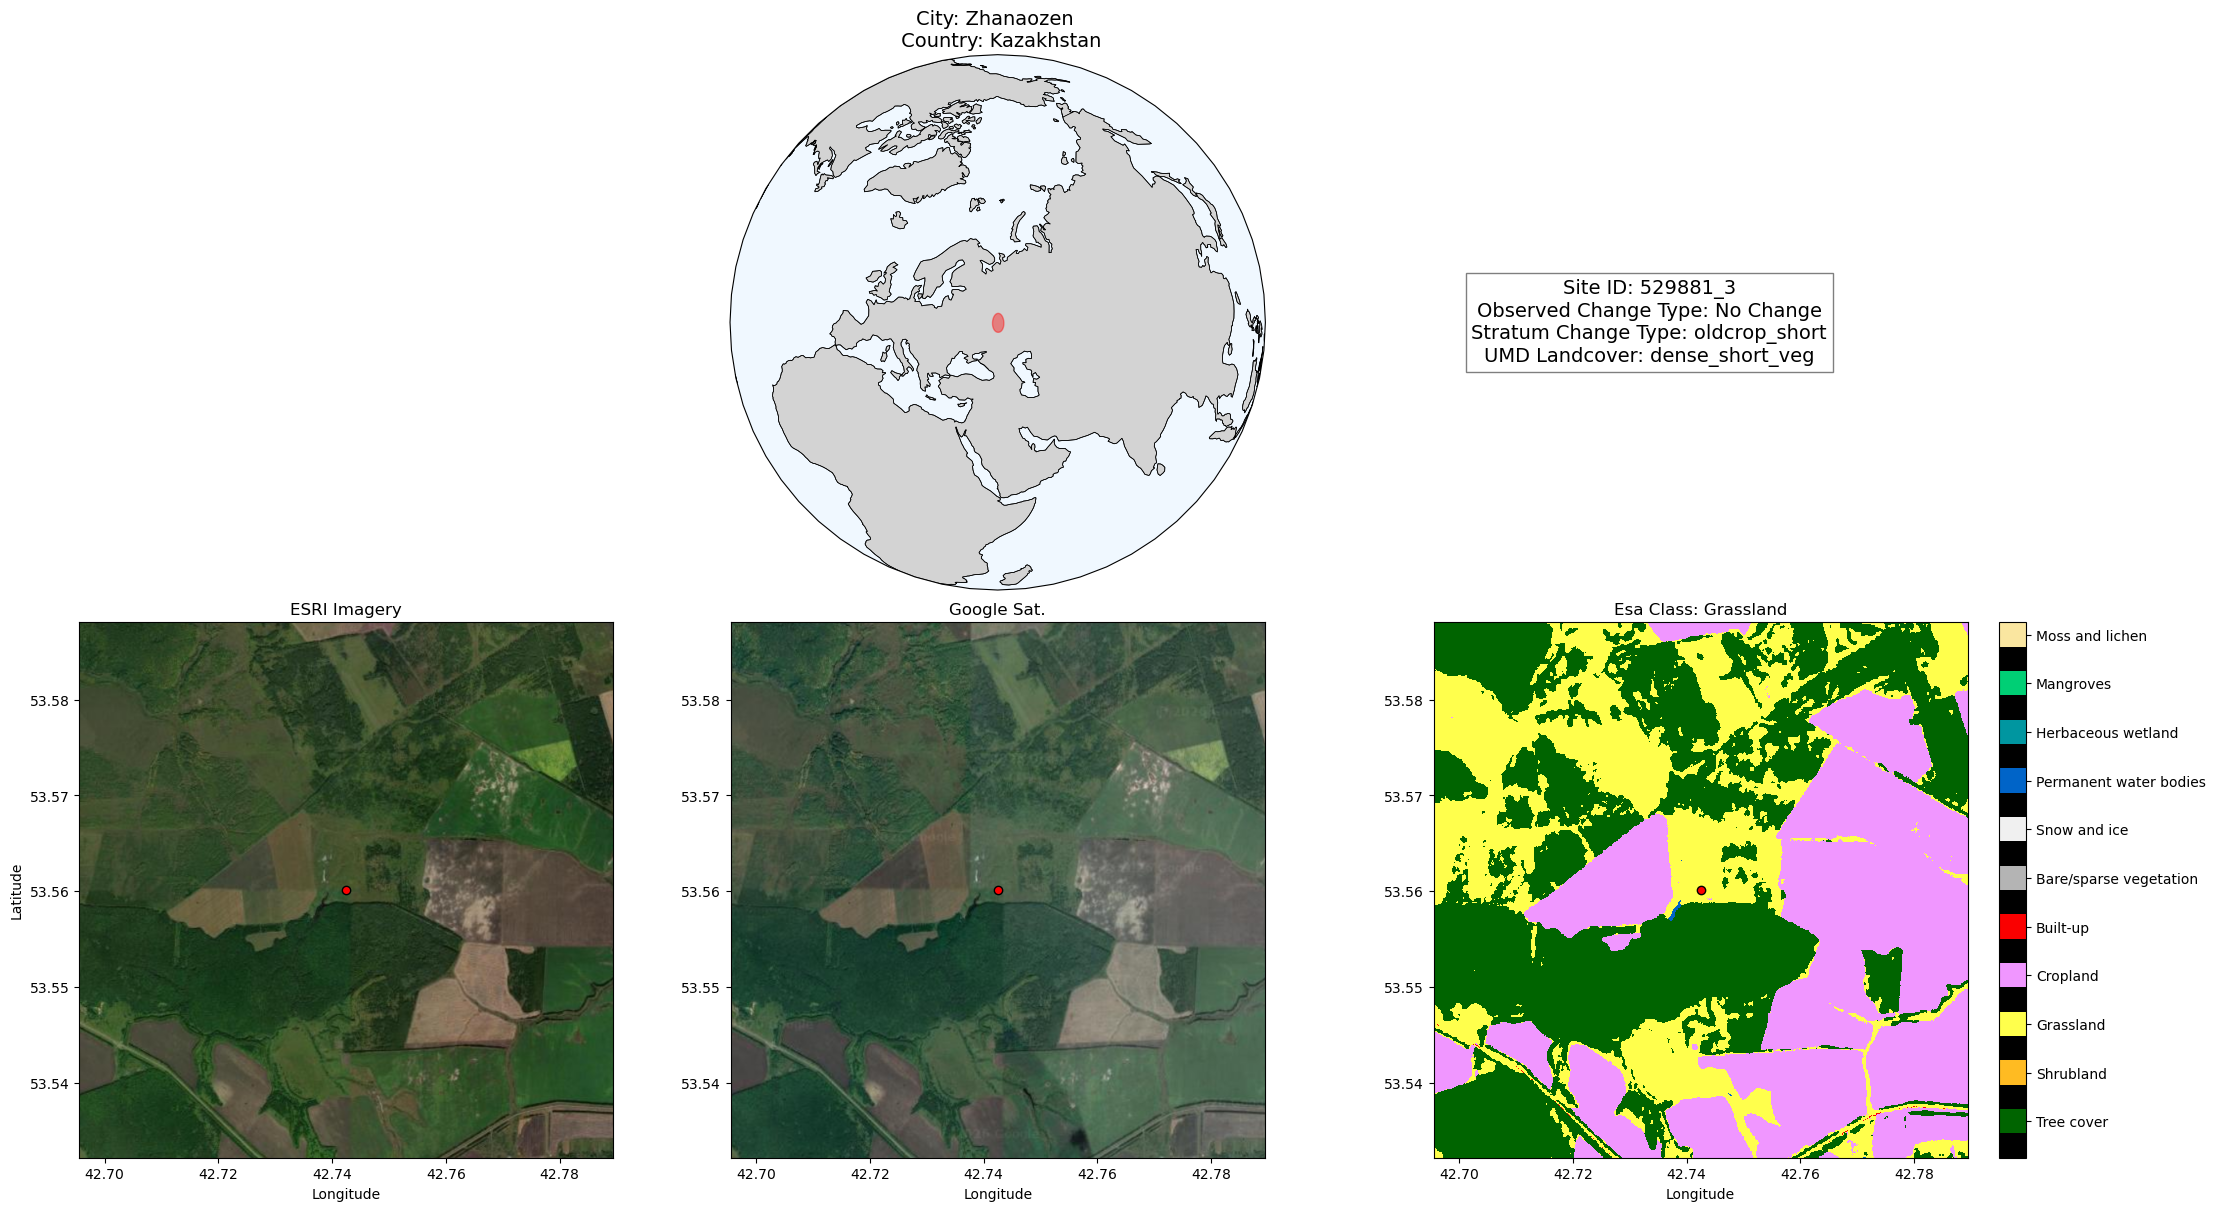

In [ ]:
from basemaps import get_basemap_for_rasterio


layout = """
.aT
ABC
"""

fig, axd = plt.subplot_mosaic(
    layout, 
    constrained_layout=True, 
    figsize=(22, 12),
)

plot_globe_in_mosaic_plot(fig, axd, 'a')

for ax_lb in 'BC':
    axd[ax_lb].sharey(axd['A'])
    # axd[l].set_yticklabels([])
    axd[ax_lb].set_xlabel('Longitude')

axd['A'].set_ylabel('Latitude')
axd['A'].set_xlabel('Longitude')

show(X_esri, transform=p_esri['transform'], ax=axd['A'])
df_point_aoi.plot(ax=axd['A'], alpha=1, color='red', ec='black')
axd['A'].set_title('ESRI Imagery')

show(X_goog, transform=p_goog['transform'], ax=axd['B'])
df_point_aoi.plot(ax=axd['B'], alpha=1, color='red', ec='black')
axd['B'].set_title('Google Sat.')

colormap = p_esa['colormap'][1]  # We store each colormap as a dictionary associated to its channel
cmap = ListedColormap([np.array(colormap[key]) / 255 for key in range(256)])
im_data = show(X_esa[0, ...], 
               transform=p_esa['transform'], 
               cmap=cmap, 
               interpolation='none', 
               vmin=0, 
               vmax=255, 
               ax=axd['C'])

im = im_data.get_images()[0]
bounds_fig = sorted([0] + [t - .5 for t in ticks] + [t + .5 for t in ticks])
cbar=fig.colorbar(im, 
                  ax=axd['C'], 
                  #shrink=0.5, 
                  #pad=0.05, 
                  boundaries=bounds_fig, 
                  cmap=cmap,
                  ticks=np.array(ticks)
                 ) 
norm = BoundaryNorm(bounds_fig, cmap.N)
cbar.set_ticklabels(tick_labels)
df_point_aoi.plot(ax=axd['C'], alpha=1, color='red', ec='black', zorder=0)
axd['C'].set_title(f'Esa Class: {esa_class}')
axd['T'].axis('off')
text = f'Site ID: {SITE_ID}\nObserved Change Type: {OBSERVED_CHANGE_TYPE}\nStratum Change Type: {STRATUM_CHANGE_TYPE}\nUMD Landcover: {UMD_LC}'
axd['T'].text(.5, .5, text, fontsize=14, bbox=dict(facecolor='white', alpha=0.5), ha='center', va='center')
fig.savefig(png_dir / '_location.png')

## DIST-S1 Panel

In [ ]:
from dist_s1_enumerator import get_mgrs_table

In [ ]:
df_mgrs = get_mgrs_table()
df_mgrs[df_mgrs.mgrs_tile_id == MGRS_TILE_ID].geometry.values[0].wkt

'POLYGON ((41.9404063166561 54.1092064475415, 42.0109107771382 53.1236450364427, 43.6511207707923 53.1535350928786, 43.6192567206008 54.1401867749597, 41.9404063166561 54.1092064475415))'

In [ ]:
dist_s1_dates[:3]

[Timestamp('2024-01-02 03:13:54+0000', tz='UTC'),
 Timestamp('2024-01-07 03:22:02+0000', tz='UTC'),
 Timestamp('2024-01-12 03:30:10+0000', tz='UTC')]

In [ ]:
def get_pre_post_rtc_indices(df_rtc: pd.DataFrame, status_date: pd.Timestamp, n_anniv=3) -> tuple[int, list[int]]:
    post_index_bool = (df_rtc.start_time - status_date).dt.total_seconds().abs() < 300
    if post_index_bool.sum() == 0:
        print('No RTC found within 5 minutes of status date; means no RTC overlapping the window bbox')
        return [None] * n_anniv, None
    post_index = post_index_bool.idxmax()
    burst_id = df_rtc.iloc[post_index].jpl_burst_id
    df_rtc_ts_burst = df_rtc[df_rtc.jpl_burst_id == burst_id]
    pre_indices = []
    for k in range(n_anniv):
        poss_ind_bool = (df_rtc_ts_burst.start_time < status_date - pd.Timedelta(days=365 * (k + 1)))
        if poss_ind_bool.sum() == 0:
            pre_index = None
        else:
            pre_index = poss_ind_bool.idxmin()
        pre_indices.append(pre_index)
    return pre_indices, post_index

for i in range(10):
    dt = dist_s1_dates[i]
    print('######')
    print(f'{i=}')
    print('dist date', dt)
    pre_indices, post_index = get_pre_post_rtc_indices(df_rtc, dt)
    pn1, p0, p1 = pre_indices
    print(p0, p1)
    if p1 is not None:
        print(df_rtc.iloc[p1].acq_time)
    if p0 is not None:
        print(df_rtc.iloc[p0].acq_time)
        print(df_rtc.iloc[post_index].acq_time)
    else:
        print('Probably should include track data in the dist information')
    print('######')




######
i=0
dist date 2024-01-02 03:13:54+00:00
No RTC found within 5 minutes of status date; means no RTC overlapping the window bbox
None None
Probably should include track data in the dist information
######
######
i=1
dist date 2024-01-07 03:22:02+00:00
No RTC found within 5 minutes of status date; means no RTC overlapping the window bbox
None None
Probably should include track data in the dist information
######
######
i=2
dist date 2024-01-12 03:30:10+00:00
32 1
2021-01-15 03:30:05+00:00
2022-01-22 03:30:10+00:00
2024-01-12 03:30:21+00:00
######
######
i=3
dist date 2024-01-14 03:13:53+00:00
No RTC found within 5 minutes of status date; means no RTC overlapping the window bbox
None None
Probably should include track data in the dist information
######
######
i=4
dist date 2024-01-19 03:22:01+00:00
No RTC found within 5 minutes of status date; means no RTC overlapping the window bbox
None None
Probably should include track data in the dist information
######
######
i=5
dist date 20

In [ ]:
import matplotlib as mpl

def create_continuous_colorbar(fig, cax, cmap_str, vmin, vmax, label, 
                           tick_pos='right', label_ha='center', label_va='bottom'):
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_str)
    
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(label, ha=label_ha, va=label_va)
    
    if tick_pos in ['left', 'right']:
        cbar.ax.yaxis.set_ticks_position(tick_pos)
        cbar.ax.yaxis.set_label_position(tick_pos)
    else:
        cbar.ax.xaxis.set_ticks_position(tick_pos)
        cbar.ax.xaxis.set_label_position(tick_pos)
        
    return cbar

In [ ]:
from time_utils import get_last_index_before

dt = dist_s1_dates[-2]
idx = get_last_index_before(dist_hls_dates, dt)
dist_hls_dates[idx], dt, dt > dist_hls_dates[idx]

(Timestamp('2024-11-22 08:11:08.619486+0000', tz='UTC'),
 Timestamp('2024-12-25 03:30:06+0000', tz='UTC'),
 True)

In [ ]:
vv_stack = np.stack([vv_arrs_tv[i] for i in range(len(vv_arrs_tv)) if vv_arrs_tv[i].shape == vv_arrs_tv[0].shape])
vh_stack = np.stack([vh_arrs_tv[i] for i in range(len(vh_arrs_tv)) if vh_arrs_tv[i].shape == vh_arrs_tv[0].shape])

vh_vmax = np.nanpercentile(vh_stack, 98)
vv_vmax = np.nanpercentile(vv_stack, 98)

<>:176: SyntaxWarning: invalid escape sequence '\g'
<>:177: SyntaxWarning: invalid escape sequence '\g'
<>:176: SyntaxWarning: invalid escape sequence '\g'
<>:177: SyntaxWarning: invalid escape sequence '\g'
/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_9397/367827913.py:176: SyntaxWarning: invalid escape sequence '\g'
  create_continuous_colorbar(fig, axd['A'], sar_cmap, 0, vv_vmax, '$\gamma_{VV}$', tick_pos='left')
/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_9397/367827913.py:177: SyntaxWarning: invalid escape sequence '\g'
  create_continuous_colorbar(fig, axd['B'], sar_cmap, 0, vh_vmax, '$\gamma_{VH}$', tick_pos='left')


pre_index=np.int64(63)
post_index=94


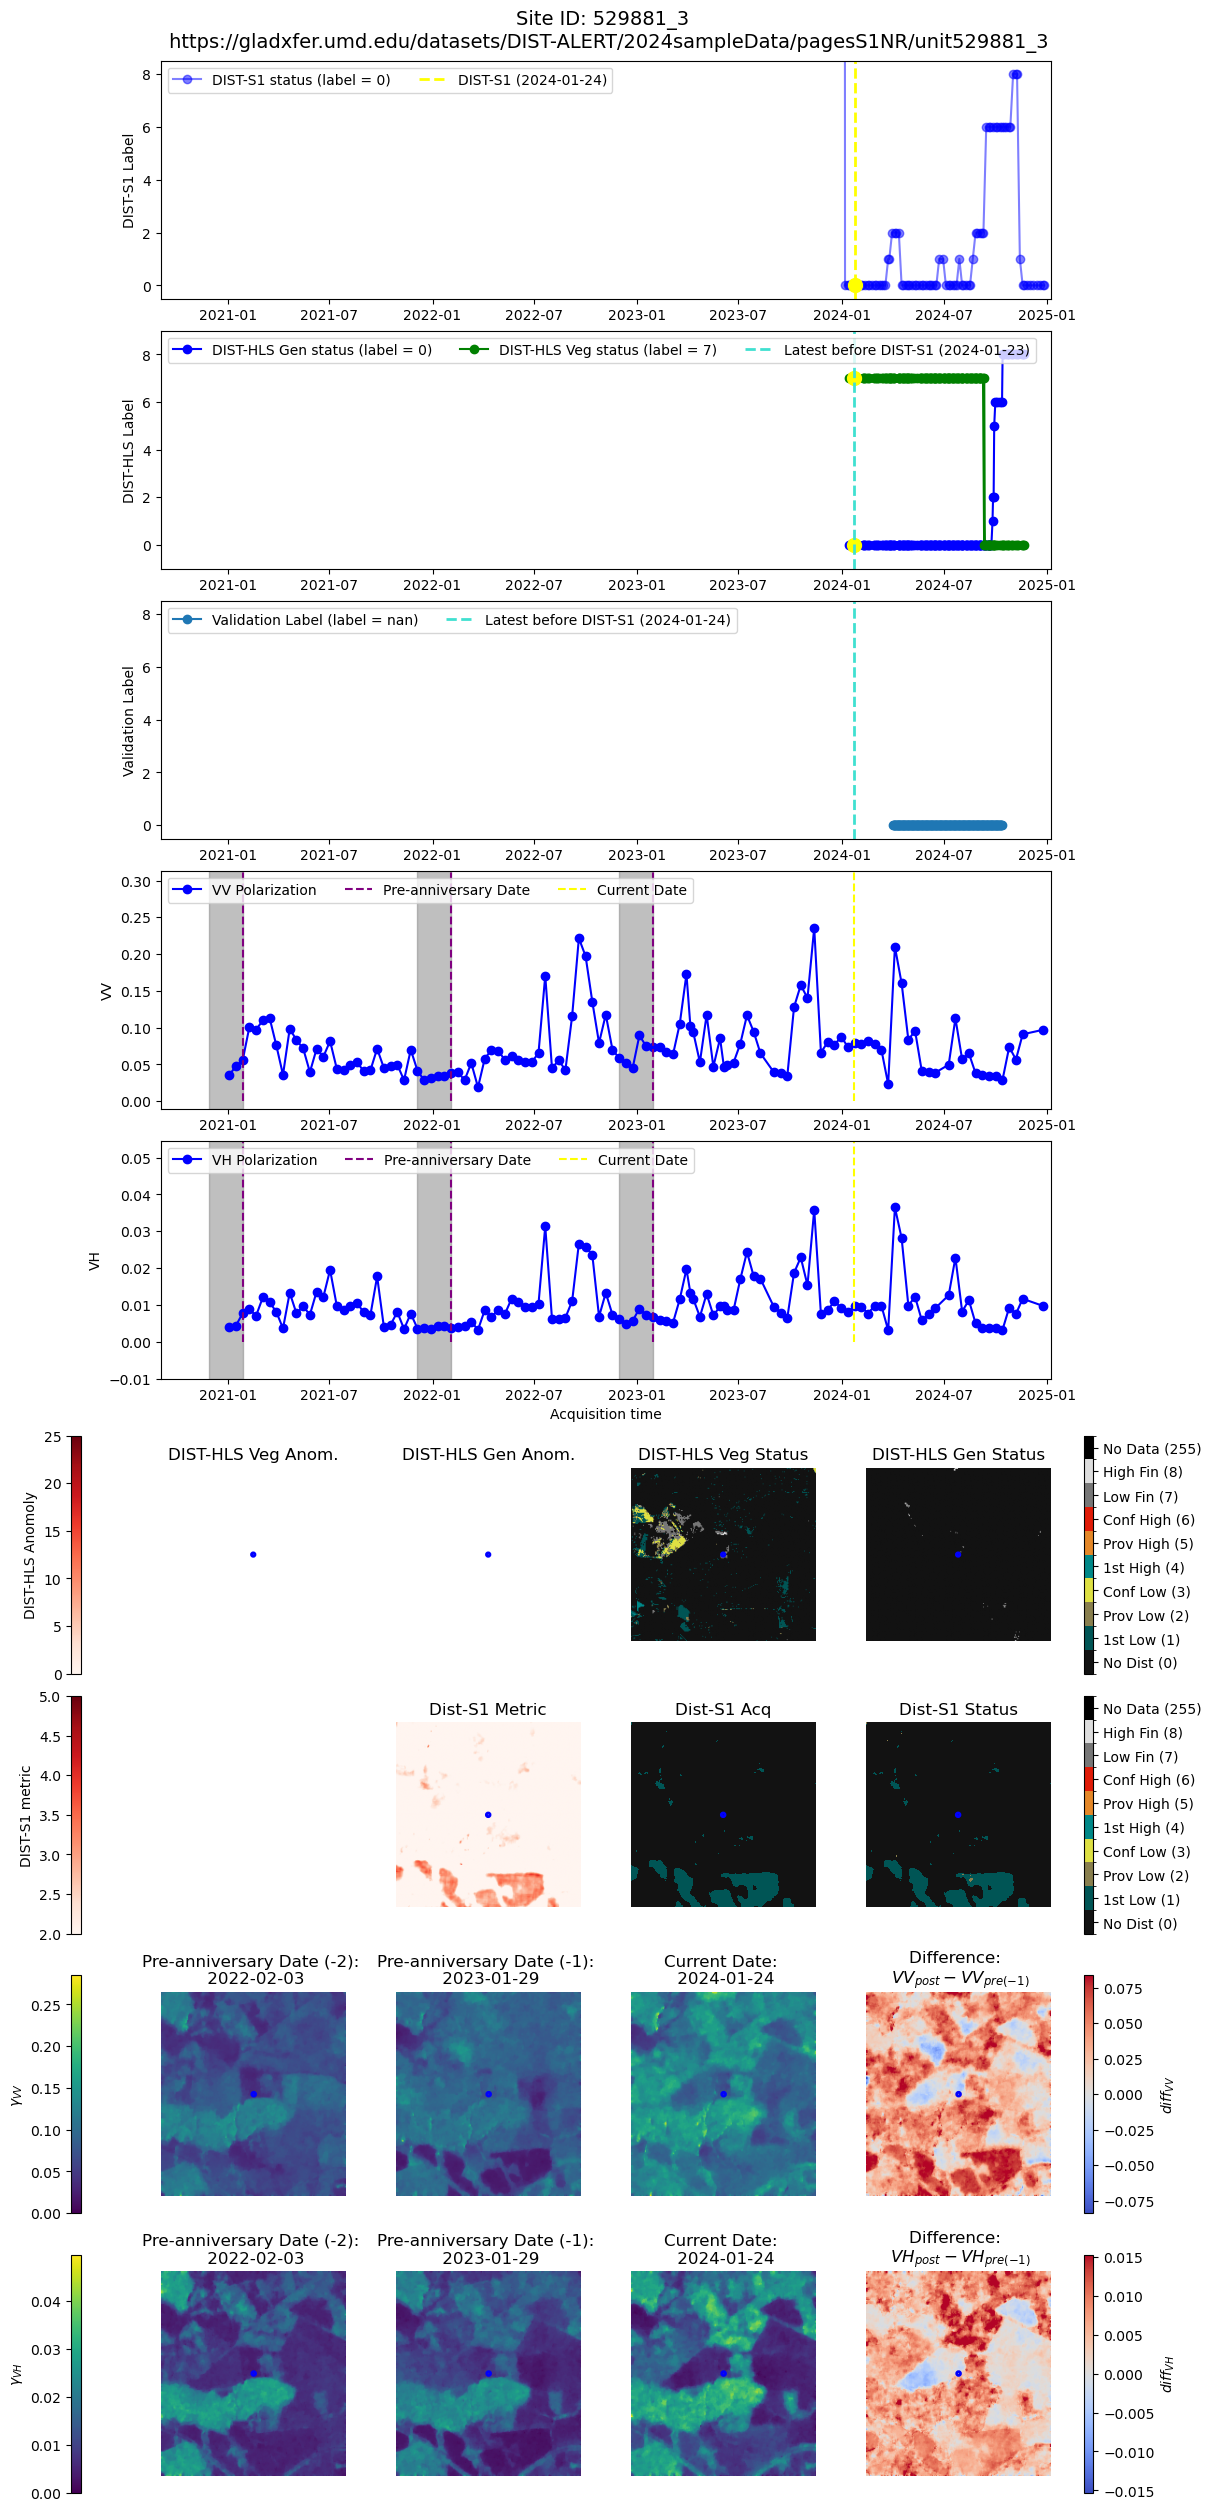

In [ ]:
def create_plot_panel(idx: int):
    layout = """
    .tttt.
    .ssss.
    .ZZZZ.
    .XXXX.
    .YYYY.
    012345
    S.mnoT
    AabcdC
    BwxyzD
    """


    dist_s1_index = idx
    dist_s1_date = dist_s1_dates[dist_s1_index]

    dist_hls_index = get_last_index_before(dist_hls_dates, dist_s1_date)
    if dist_hls_index is None:
        dist_hls_index = 0
    val_index = get_last_index_before(df_site_ts.date, dist_s1_date)

    pre_indices, post_index = get_pre_post_rtc_indices(df_rtc, dist_s1_date)

    pre_index, pre_index_earliest, pre_index_earliest_2 = pre_indices
    print(f'{pre_index=}')
    print(f'{post_index=}')

    diff_cmap='coolwarm'
    sar_cmap='viridis'
    metric_cmap='Reds'

    metric_vmin=2
    metric_vmax=5

    anom_vmax=25

    fig, axd = plt.subplot_mosaic(
        layout, 
        constrained_layout=True, 
        figsize=(12, 25),
        gridspec_kw={'width_ratios': [0.05, 1, 1, 1, 1, 0.05]}
    )
    fig.suptitle(f'Site ID: {SITE_ID} \n https://gladxfer.umd.edu/datasets/DIST-ALERT/2024sampleData/pagesS1NR/unit{SITE_ID}', fontsize=14)


    date_rtc_pre2 = df_rtc.acq_time[pre_index_earliest].date() if pre_index_earliest is not None else 'No Data'
    date_rtc_pre = df_rtc.acq_time[pre_index].date() if pre_index is not None else 'No Data'
    date_rtc_post = df_rtc.acq_time[post_index].date() if post_index is not None else 'No Data'

    ts_rtc_pre3 = df_rtc.acq_time[pre_index_earliest_2] if pre_index_earliest_2 is not None else None
    ts_rtc_pre2 = df_rtc.acq_time[pre_index_earliest] if pre_index_earliest is not None else None
    ts_rtc_pre = df_rtc.acq_time[pre_index].date() if pre_index is not None else None
    ts_rtc_post = df_rtc.acq_time[post_index].date() if post_index is not None else None

    for (ax_label, arr, pol, vmax) in zip('XY', [vv_pixel_ts,vh_pixel_ts], ['VV', 'VH'], [vv_vmax, vh_vmax]):
        ax_ts = axd[ax_label]
        sar_ts = ax_ts.plot(rtc_dates, arr, marker='o', color='blue', label=f'{pol} Polarization')
        ax_ts.set_ylabel(f'{pol}')
        #nan_ln = ax_ts.plot(rtc_dates_nans, rtc_nans, marker='o', color='green', label='No observation')
        ax_ts.set_ylim(-.01, vmax * 1.1)
        _, ymax = ax_ts.get_ylim()

        lns = []
        for color, label, date in [('purple', 'Pre-anniversary Date', ts_rtc_pre3), 
                                   ('purple', 'Pre-anniversary Date', ts_rtc_pre2), 
                                   ('purple', 'Pre-anniversary Date', ts_rtc_pre), 
                                   ('yellow', 'Current Date', ts_rtc_post)]:
            ls = '--'
            if date is not None:
                ax_ts.vlines(date, 0, ymax, color=color, label=label, ls='--')
            if date is not None and label != 'Current Date':
                ax_ts.axvspan(pd.to_datetime(date, utc=True) - pd.Timedelta(days=60), pd.to_datetime(date, utc=True), color='gray', alpha=.5)
        for color, label in [('purple', 'Pre-anniversary Date'), 
                             ('yellow', 'Current Date')]:
            ls = '--'
            ln = Line2D([0], [0], color=color, linestyle=ls, label=label)
            lns.append(ln)
        
        
        lns = sar_ts + lns
        labs = [line.get_label() for line in lns]
        ax_ts.legend(lns, labs, loc='upper left', ncol=4)


    axd['t'].plot(dist_s1_dates, dist_status_ts, marker='o', color='blue', alpha=.5, label=f'DIST-S1 status (label = {dist_status_ts[dist_s1_index]})')
    axd['t'].plot(dist_s1_dates[dist_s1_index: dist_s1_index+1], 
                 dist_status_ts[dist_s1_index: dist_s1_index+1], marker='o', markersize=10, color='yellow', alpha=1)
    axd['t'].axvline(dist_s1_date, color='yellow', ls='--', alpha=1, linewidth=2, label=f'DIST-S1 ({dist_s1_date.date()})')
    axd['t'].set_ylabel('DIST-S1 Label')
    axd['t'].set_ylim(-.5, 8.5)
    axd['t'].legend(loc='upper left', ncol=4)

    axd['s'].plot(dist_hls_dates, hls_gen_status_ts, marker='o', label=f'DIST-HLS Gen status (label = {hls_gen_status_ts[dist_hls_index]})', color='blue')
    axd['s'].plot(dist_hls_dates, hls_veg_status_ts, marker='o', label=f'DIST-HLS Veg status (label = {hls_veg_status_ts[dist_hls_index]})', color='green')
    axd['s'].plot(dist_hls_dates[dist_hls_index: dist_hls_index+1], 
                hls_gen_status_ts[dist_hls_index: dist_hls_index+1], marker='o', color='yellow', alpha=1, markersize=10)
    axd['s'].plot(dist_hls_dates[dist_hls_index: dist_hls_index+1], 
                hls_veg_status_ts[dist_hls_index: dist_hls_index+1], marker='o', color='yellow', alpha=1, markersize=10)
    axd['s'].axvline(dist_hls_dates[dist_hls_index], color='turquoise', ls='--', alpha=1, linewidth=2, label=f'Latest before DIST-S1 ({dist_hls_dates[dist_hls_index].date()})')
    axd['s'].legend(loc='upper left', ncol=4)

    axd['Z'].plot(df_site_ts.date, df_site_ts.observation_label, marker='o', label=f'Validation Label (label = {df_site_ts.observation_label.iloc[val_index]})')
    axd['Z'].plot(df_site_ts.date.iloc[val_index], df_site_ts.observation_label.iloc[val_index], marker='o', color='yellow', alpha=1, markersize=10)

    axd['Z'].set_ylabel('Validation Label')
    axd['Z'].axvline(df_site_ts.date.iloc[val_index], color='turquoise', ls='--', alpha=1, linewidth=2, label=f'Latest before DIST-S1 ({df_site_ts.date.iloc[val_index].date()})')
    axd['Z'].legend(loc='upper left', ncol=4)


    axd['s'].set_ylim(-1, 9)
    for ax_lb in 'tZ':
        axd[ax_lb].sharey(axd['t'])
    axd['s'].set_ylabel('DIST-HLS Label')

    create_continuous_colorbar(fig, axd['0'], metric_cmap, 0, anom_vmax, 'DIST-HLS Anomoly', tick_pos='left')

    veg_anom_arr_plot = np.ma.masked_equal(hls_veg_anom_arrs[dist_hls_index], 255)
    axd['1'].imshow(veg_anom_arr_plot, vmin=0, vmax=anom_vmax, cmap=metric_cmap)
    axd['1'].set_title('DIST-HLS Veg Anom.')
    gen_anom_arr_plot = np.ma.masked_equal(hls_gen_anom_arrs[dist_hls_index], -1)
    axd['2'].set_title('DIST-HLS Gen Anom.')
    axd['2'].imshow(gen_anom_arr_plot, vmin=0, vmax=anom_vmax, cmap = metric_cmap)

    axd['3'].set_title('DIST-HLS Veg Status')
    axd['3'].imshow(hls_veg_status_arrs[dist_hls_index], cmap=dist_cmap, norm=dist_norm)
    axd['4'].set_title('DIST-HLS Gen Status')
    axd['4'].imshow(hls_gen_status_arrs[dist_hls_index], cmap=dist_cmap, norm=dist_norm)
    add_dist_s1_colorbar(axd['5'])



    axd['Y'].set_xlim(rtc_start_request - pd.Timedelta(days=window_size_days * 2), ts_end_dist + pd.Timedelta(days=7))
    for ax_lb in 'tsXZ':
        axd[ax_lb].sharex(axd['Y'])
    axd['Y'].set_xlabel('Acquisition time')

    axd['m'].set_title('Dist-S1 Metric')
    axd['m'].imshow(dist_metric_image_ts[dist_s1_index], cmap=metric_cmap, vmin=metric_vmin, vmax=metric_vmax)
    axd['n'].set_title('Dist-S1 Acq')
    axd['n'].imshow(dist_acq_image_ts[dist_s1_index], cmap=dist_cmap, norm=dist_norm, interpolation='none')
    axd['o'].set_title('Dist-S1 Status')
    axd['o'].imshow(dist_status_image_ts[dist_s1_index], cmap=dist_cmap, norm=dist_norm, interpolation='none')

    vv_pre2 = vv_arrs_tv[pre_index_earliest] if pre_index_earliest is not None else np.full_like(vv_arrs_tv[0], np.nan)
    vv_pre = vv_arrs_tv[pre_index] if pre_index is not None else np.full_like(vv_arrs_tv[0], np.nan)
    vv_post = vv_arrs_tv[post_index] if post_index is not None else np.full_like(vv_arrs_tv[0], np.nan)
    diff_vv = vv_post - vv_pre

    vh_pre2 = vh_arrs_tv[pre_index_earliest] if pre_index_earliest is not None else np.full_like(vh_arrs_tv[0], np.nan)
    vh_pre = vh_arrs_tv[pre_index] if pre_index is not None else np.full_like(vh_arrs_tv[0], np.nan)
    vh_post = vh_arrs_tv[post_index] if post_index is not None else np.full_like(vh_arrs_tv[0], np.nan)
    diff_vh = vh_post - vh_pre

    diff_vv_vis=max(np.nanpercentile(np.abs(diff_vv), 98), .0001)
    diff_vh_vis=max(np.nanpercentile(np.abs(diff_vh), 98), .0000005)

    axd['a'].imshow(vv_pre2, vmin=0, vmax=vv_vmax)
    axd['a'].set_title(f'Pre-anniversary Date (-2): \n {date_rtc_pre2}')
    axd['b'].imshow(vv_pre, vmin=0, vmax=vv_vmax)
    axd['b'].set_title(f'Pre-anniversary Date (-1): \n {date_rtc_pre}')
    axd['c'].imshow(vv_post, vmin=0, vmax=vv_vmax)
    axd['c'].set_title(f'Current Date: \n {date_rtc_post}')
    axd['d'].imshow(diff_vv, vmin=-diff_vv_vis, vmax=diff_vv_vis, cmap=diff_cmap)
    axd['d'].set_title('Difference: \n $VV_{post} - VV_{pre (-1)}$')

    axd['w'].imshow(vh_pre2, vmin=0, vmax=vh_vmax, cmap=sar_cmap)
    axd['w'].set_title(f'Pre-anniversary Date (-2): \n {date_rtc_pre2}')
    axd['x'].imshow(vh_pre, vmin=0, vmax=vh_vmax, cmap=sar_cmap)
    axd['x'].set_title(f'Pre-anniversary Date (-1): \n {date_rtc_pre}')
    axd['y'].imshow(vh_post, vmax=vh_vmax, cmap=sar_cmap)
    axd['y'].set_title(f'Current Date: \n {date_rtc_post}')
    axd['z'].imshow(diff_vh, cmap=diff_cmap, vmin=-diff_vh_vis, vmax=diff_vh_vis)
    axd['z'].set_title('Difference: \n $VH_{post} - VH_{pre (-1)}$')

    create_continuous_colorbar(fig, axd['A'], sar_cmap, 0, vv_vmax, '$\gamma_{VV}$', tick_pos='left')
    create_continuous_colorbar(fig, axd['B'], sar_cmap, 0, vh_vmax, '$\gamma_{VH}$', tick_pos='left')

    create_continuous_colorbar(fig, axd['C'], diff_cmap, -diff_vv_vis, diff_vv_vis, '$diff_{VV}$', tick_pos='right')
    create_continuous_colorbar(fig, axd['D'], diff_cmap, -diff_vh_vis, diff_vh_vis, '$diff_{VH}$', tick_pos='right')
    create_continuous_colorbar(fig, axd['S'], metric_cmap, metric_vmin, metric_vmax, 'DIST-S1 metric', tick_pos='left')

    add_dist_s1_colorbar(axd['T'])

    for a in 'abcdwxyzmno1234':
        axd[a].axis('off')

    if post_index is not None:
        for a in 'abcdwxyz':
            # Note Circle expects xy or col, row (not row col)
            circle = plt.Circle(centers_rtc[post_index][::-1], 2, color='blue', fill=False, linewidth=2, alpha=1, zorder=10)
            axd[a].add_patch(circle)

    for a in 'mno':
        # Note Circle expects xy or col, row (not row col)
        circle = plt.Circle(center_dist_s1[::-1], 2, color='blue', fill=False, linewidth=2, alpha=1, zorder=10)
        axd[a].add_patch(circle)

    for a in '1234':
        circle = plt.Circle(centers_dist_hls[0][::-1], 2, color='blue', fill=False, linewidth=2, alpha=1, zorder=10)
        axd[a].add_patch(circle)
    
    return fig, axd
f, _ = create_plot_panel(5)

In [ ]:
for k in tqdm(range(len(dist_s1_dates))):
    f, _ = create_plot_panel(k)
    f.savefig(png_dir / f'panel_{k}.png')
    plt.close('all')

  0%|          | 0/88 [00:00<?, ?it/s]

No RTC found within 5 minutes of status date; means no RTC overlapping the window bbox
pre_index=None
post_index=None


  1%|          | 1/88 [00:00<01:07,  1.28it/s]

No RTC found within 5 minutes of status date; means no RTC overlapping the window bbox
pre_index=None
post_index=None


  2%|▏         | 2/88 [00:01<01:08,  1.26it/s]

...

 98%|█████████▊| 86/88 [01:17<00:01,  1.20it/s]

pre_index=np.int64(92)
post_index=119


 99%|█████████▉| 87/88 [01:18<00:00,  1.14it/s]

No RTC found within 5 minutes of status date; means no RTC overlapping the window bbox
pre_index=None
post_index=None


100%|██████████| 88/88 [01:19<00:00,  1.11it/s]


In [ ]:
def sorter(path: Path):
    fn = path.stem
    if 'panel' in fn:
        return int(fn.split('_')[1])
    else:
        return -1

png_imgs = sorted(list(png_dir.glob('*.png')), key=sorter)
png_imgs[:3]

[PosixPath('out/529881_3/pngs/_location.png'),
 PosixPath('out/529881_3/pngs/panel_0.png'),
 PosixPath('out/529881_3/pngs/panel_1.png')]

In [ ]:
with open(site_dir / f'ts_{SITE_ID}.pdf', "wb") as f:
    f.write(img2pdf.convert(png_imgs))

Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an a